


CSV format (sequential):
 `length, avg, stdev, min, max, valid`  

CSV format (parallel):
 `threads, length, avg, stdev, min, max, valid`

# Utilities

In [1]:
import subprocess
import os
import random
import re
import math
import statistics
import time
import csv
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

plt.rcParams.update({
    "figure.dpi"       : 130,
    "axes.grid"        : True,
    "grid.alpha"       : 0.35,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})

In [2]:
# ── Shared utilities ──────────────────────────────────────────────────────

# Input cache — same seeded random signal for every benchmark
_input_cache = {}

def _gen_signal(length: int) -> str:
    """Returns newline-joined floats for a seeded random signal."""
    if length not in _input_cache:
        random.seed(length)
        vals = [round(random.uniform(-100, 100), 6) for _ in range(length)]
        _input_cache[length] = "\n".join(map(str, vals))
    return _input_cache[length]

def build_input_sequential(length: int) -> str:
    """For sequential C++ files: reads signal_length then signal values."""
    return f"{length}\n{_gen_signal(length)}"

def build_input_sequential_no_signal(length: int) -> str:
    """For sequential C++ files: reads signal_length then signal values."""
    return f"{length}\n"

def build_input_parallel(length: int, threads: int) -> str:
    """For parallel C++ files: reads signal_length, values, then num_threads."""
    return f"{length}\n{_gen_signal(length)}\n{threads}"

def build_input_parallel_no_signal(length: int, threads: int) -> str:
    """For C++ files that generate their own signal internally.
       Reads only: signal_length then num_threads."""
    return f"{length}\n{threads}"

def parse_time(output: str):
    m = re.search(r"Time:\s*([\d.eE+\-]+)\s*seconds", output)
    return float(m.group(1)) if m else None

def compile_cpp(cpp_file: str, binary: str, flags: list):
    assert os.path.isfile(cpp_file), f"Not found: {cpp_file}"
    cmd = ["g++", cpp_file, "-o", binary] + flags
    print("Compiling:", " ".join(cmd))
    res = subprocess.run(cmd, capture_output=True, text=True)
    if res.returncode != 0:
        raise RuntimeError(f"[COMPILE ERROR]\n{res.stderr}")
    print("[OK] Compiled\n")

def run_once(binary: str, stdin_data: str, timeout: int = 120):
    try:
        r = subprocess.run([binary], input=stdin_data,
                           capture_output=True, text=True, timeout=timeout)
        return parse_time(r.stdout) if r.returncode == 0 else None
    except subprocess.TimeoutExpired:
        return None

def benchmark_sequential(binary: str, length: int, num_runs: int) -> dict:
    data = build_input_sequential(length)
    run_once(binary, data)  # warmup
    times = [t for _ in range(num_runs) if (t := run_once(binary, data)) is not None]
    if not times:
        return dict(length=length, avg=None, stdev=None, min=None, max=None, valid=0)
    return dict(
        length=length,
        avg=statistics.mean(times),
        stdev=statistics.stdev(times) if len(times) > 1 else 0.0,
        min=min(times), max=max(times), valid=len(times),
    )

def benchmark_parallel(binary: str, threads: int, length: int, num_runs: int) -> dict:
    data = build_input_parallel_no_signal(length, threads)
    run_once(binary, data)  # warmup
    times = [t for _ in range(num_runs) if (t := run_once(binary, data)) is not None]
    if not times:
        return dict(threads=threads, length=length, avg=None, stdev=None, min=None, max=None, valid=0)
    return dict(
        threads=threads, length=length,
        avg=statistics.mean(times),
        stdev=statistics.stdev(times) if len(times) > 1 else 0.0,
        min=min(times), max=max(times), valid=len(times),
    )

def save_csv_sequential(results: list, path: str):
    """CSV format: length, avg, stdev, min, max, valid"""
    with open(path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=["length","avg","stdev","min","max","valid"])
        writer.writeheader()
        writer.writerows(results)
    print(f"[CSV] Saved {len(results)} rows → {path}")

def save_csv_parallel(results: list, path: str):
    """CSV format: threads, length, avg, stdev, min, max, valid"""
    with open(path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=["threads","length","avg","stdev","min","max","valid"])
        writer.writeheader()
        writer.writerows(results)
    print(f"[CSV] Saved {len(results)} rows → {path}")

def load_csv_sequential(path: str) -> dict:
    """Returns {length: avg_time}"""
    result = {}
    with open(path) as f:
        for row in csv.DictReader(f):
            if row["avg"] not in ("", "None"):
                result[int(row["length"])] = float(row["avg"])
    return result

def load_csv_parallel(path: str) -> dict:
    """Returns {(threads, length): avg_time}"""
    result = {}
    with open(path) as f:
        for row in csv.DictReader(f):
            if row["avg"] not in ("", "None", "nan"):
                result[(int(row["threads"]), int(row["length"]))] = float(row["avg"])
    return result


# Sequential Recursive


In [3]:
SEQ_REC_CPP    = "../src/cooley_tukey_sequential.cpp"  # ← update path if needed
SEQ_REC_BIN    = "./bin_seq_rec"
SEQ_REC_CSV    = "seq_recursive.csv"
SEQ_REC_FLAGS  = ["-O2", "-std=c++17"]
SEQ_REC_RUNS   = 20
SEQ_REC_SIZES  = [2**p for p in range(1, 26)]   # 2^1 … 2^20

In [4]:
compile_cpp(SEQ_REC_CPP, SEQ_REC_BIN, SEQ_REC_FLAGS)

seq_rec_results = []
t0 = time.time()
for i, length in enumerate(SEQ_REC_SIZES, 1):
    r = benchmark_sequential(SEQ_REC_BIN, length, SEQ_REC_RUNS)
    seq_rec_results.append(r)
    avg_str = f"{r['avg']:.6f}s" if r['avg'] else "FAILED"
    print(f"[{i:>2}/{len(SEQ_REC_SIZES)}] N=2^{int(math.log2(length)):<2} ({length:<8}) avg={avg_str}")

print(f"\nDone in {time.time()-t0:.1f}s")
save_csv_sequential(seq_rec_results, SEQ_REC_CSV)

Compiling: g++ ../src/cooley_tukey_sequential.cpp -o ./bin_seq_rec -O2 -std=c++17
[OK] Compiled

[ 1/25] N=2^1  (2       ) avg=0.000000s
[ 2/25] N=2^2  (4       ) avg=0.000001s
[ 3/25] N=2^3  (8       ) avg=0.000001s
[ 4/25] N=2^4  (16      ) avg=0.000002s
[ 5/25] N=2^5  (32      ) avg=0.000003s
[ 6/25] N=2^6  (64      ) avg=0.000005s
[ 7/25] N=2^7  (128     ) avg=0.000010s
[ 8/25] N=2^8  (256     ) avg=0.000023s
[ 9/25] N=2^9  (512     ) avg=0.000043s
[10/25] N=2^10 (1024    ) avg=0.000081s
[11/25] N=2^11 (2048    ) avg=0.000158s
[12/25] N=2^12 (4096    ) avg=0.000303s
[13/25] N=2^13 (8192    ) avg=0.000627s
[14/25] N=2^14 (16384   ) avg=0.001308s
[15/25] N=2^15 (32768   ) avg=0.002702s
[16/25] N=2^16 (65536   ) avg=0.005633s
[17/25] N=2^17 (131072  ) avg=0.011643s
[18/25] N=2^18 (262144  ) avg=0.024119s
[19/25] N=2^19 (524288  ) avg=0.066222s
[20/25] N=2^20 (1048576 ) avg=0.106790s
[21/25] N=2^21 (2097152 ) avg=0.217625s
[22/25] N=2^22 (4194304 ) avg=0.438354s
[23/25] N=2^23 (8388608

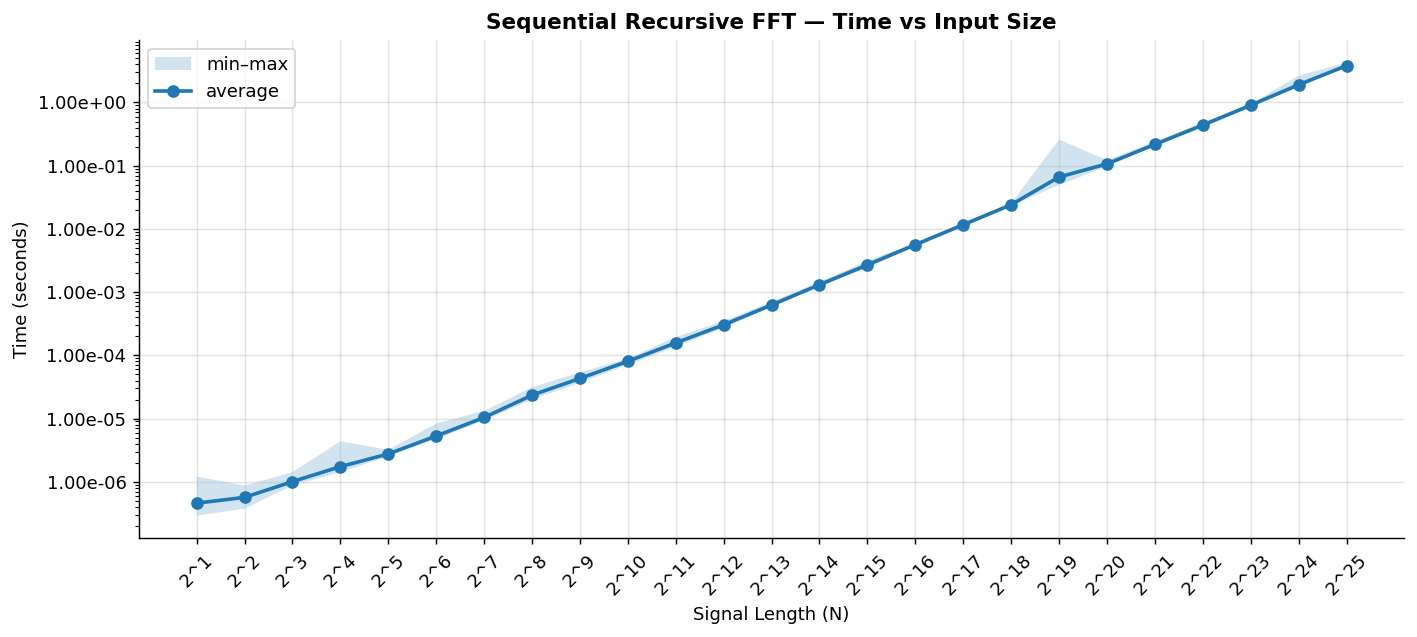

In [5]:
# Plot: Sequential Recursive — Time vs Signal Size
rows = [r for r in seq_rec_results if r['avg'] is not None]
xi   = list(range(len(rows)))
xlabs = [f"2^{int(math.log2(r['length']))}" for r in rows]

fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(xi, [r['min'] for r in rows], [r['max'] for r in rows], alpha=0.2, label='min–max')
ax.plot(xi, [r['avg'] for r in rows], 'o-', linewidth=2, label='average')
ax.set_xticks(xi); ax.set_xticklabels(xlabs, rotation=45)
ax.set_xlabel('Signal Length (N)'); ax.set_ylabel('Time (seconds)')
ax.set_title('Sequential Recursive FFT — Time vs Input Size', fontweight='bold')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2e'))
ax.legend(); plt.tight_layout(); plt.show()


# Sequential Iterative


In [6]:
SEQ_IT_CPP    = "../src/cooley_tukey_iterative.cpp"  # ← update path if needed
SEQ_IT_BIN    = "./bin_seq_it"
SEQ_IT_CSV    = "seq_iterative.csv"
SEQ_IT_FLAGS  = ["-O2", "-std=c++17"]
SEQ_IT_RUNS   = 20
SEQ_IT_SIZES  = [2**p for p in range(1, 26)]   # 2^1 … 2^20

In [7]:
compile_cpp(SEQ_IT_CPP, SEQ_IT_BIN, SEQ_IT_FLAGS)

seq_it_results = []
t0 = time.time()
for i, length in enumerate(SEQ_IT_SIZES, 1):
    r = benchmark_sequential(SEQ_IT_BIN, length, SEQ_IT_RUNS)
    seq_it_results.append(r)
    avg_str = f"{r['avg']:.6f}s" if r['avg'] else "FAILED"
    print(f"[{i:>2}/{len(SEQ_IT_SIZES)}] N=2^{int(math.log2(length)):<2} ({length:<8}) avg={avg_str}")

print(f"\nDone in {time.time()-t0:.1f}s")
save_csv_sequential(seq_it_results, SEQ_IT_CSV)

Compiling: g++ ../src/cooley_tukey_iterative.cpp -o ./bin_seq_it -O2 -std=c++17
[OK] Compiled

[ 1/25] N=2^1  (2       ) avg=0.000001s
[ 2/25] N=2^2  (4       ) avg=0.000001s
[ 3/25] N=2^3  (8       ) avg=0.000001s
[ 4/25] N=2^4  (16      ) avg=0.000001s
[ 5/25] N=2^5  (32      ) avg=0.000001s
[ 6/25] N=2^6  (64      ) avg=0.000001s
[ 7/25] N=2^7  (128     ) avg=0.000002s
[ 8/25] N=2^8  (256     ) avg=0.000004s
[ 9/25] N=2^9  (512     ) avg=0.000007s
[10/25] N=2^10 (1024    ) avg=0.000015s
[11/25] N=2^11 (2048    ) avg=0.000037s
[12/25] N=2^12 (4096    ) avg=0.000070s
[13/25] N=2^13 (8192    ) avg=0.000146s
[14/25] N=2^14 (16384   ) avg=0.000313s
[15/25] N=2^15 (32768   ) avg=0.000668s
[16/25] N=2^16 (65536   ) avg=0.001353s
[17/25] N=2^17 (131072  ) avg=0.002912s
[18/25] N=2^18 (262144  ) avg=0.006463s
[19/25] N=2^19 (524288  ) avg=0.013414s
[20/25] N=2^20 (1048576 ) avg=0.028280s
[21/25] N=2^21 (2097152 ) avg=0.066054s
[22/25] N=2^22 (4194304 ) avg=0.144714s
[23/25] N=2^23 (8388608 )

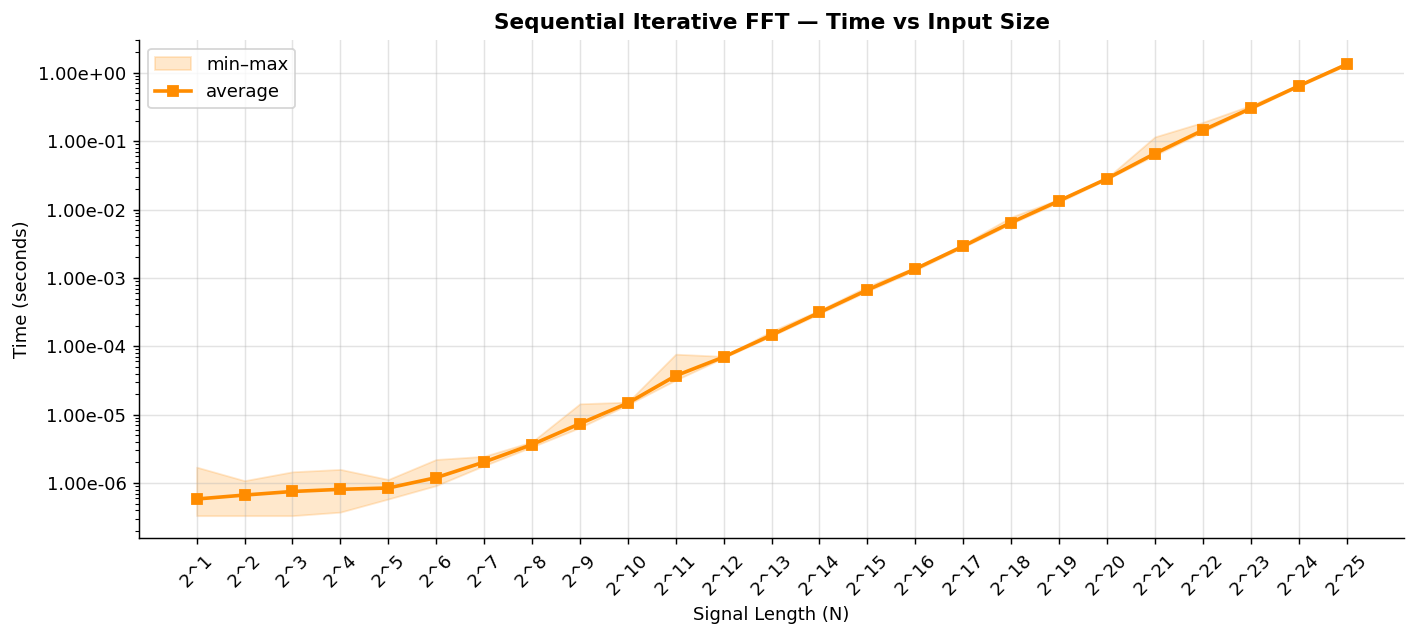

In [8]:
# Plot: Sequential Iterative — Time vs Signal Size
rows = [r for r in seq_it_results if r['avg'] is not None]
xi   = list(range(len(rows)))
xlabs = [f"2^{int(math.log2(r['length']))}" for r in rows]

fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(xi, [r['min'] for r in rows], [r['max'] for r in rows], alpha=0.2, color='darkorange', label='min–max')
ax.plot(xi, [r['avg'] for r in rows], 's-', color='darkorange', linewidth=2, label='average')
ax.set_xticks(xi); ax.set_xticklabels(xlabs, rotation=45)
ax.set_xlabel('Signal Length (N)'); ax.set_ylabel('Time (seconds)')
ax.set_title('Sequential Iterative FFT — Time vs Input Size', fontweight='bold')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2e'))
ax.legend(); plt.tight_layout(); plt.show()

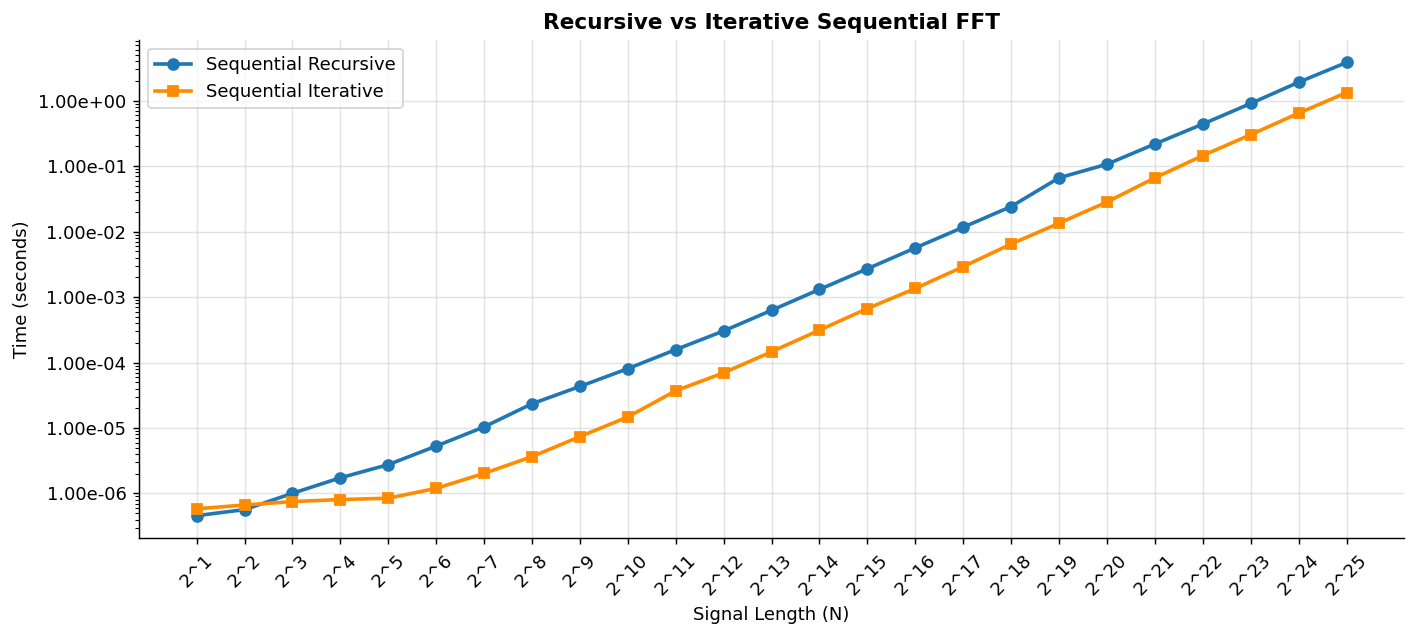

In [9]:
# Plot: Recursive vs Iterative Sequential — side-by-side comparison
seq_rec_data = load_csv_sequential(SEQ_REC_CSV)
seq_it_data  = load_csv_sequential(SEQ_IT_CSV)

common = sorted(set(seq_rec_data) & set(seq_it_data))
xi = list(range(len(common)))
xlabs = [f"2^{int(math.log2(s))}" for s in common]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(xi, [seq_rec_data[s] for s in common], 'o-', linewidth=2, label='Sequential Recursive')
ax.plot(xi, [seq_it_data[s]  for s in common], 's-', color='darkorange', linewidth=2, label='Sequential Iterative')
ax.set_xticks(xi); ax.set_xticklabels(xlabs, rotation=45)
ax.set_xlabel('Signal Length (N)'); ax.set_ylabel('Time (seconds)')
ax.set_title('Recursive vs Iterative Sequential FFT', fontweight='bold')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2e'))
ax.legend(); plt.tight_layout(); plt.show()


#  Recursive Parallel 

In [10]:
REC_PAR_CPP    = "../src/cooley_tukey_recursive_parallel.cpp"  # ← update path if needed
REC_PAR_BIN    = "./bin_rec_par"
REC_PAR_CSV    = "rec_parallel.csv"
REC_PAR_FLAGS  = ["-O2", "-std=c++17", "-pthread"]
REC_PAR_RUNS   = 20
REC_PAR_SIZES   = [2**p for p in range(1, 26)]   # 2^1 … 2^20
REC_PAR_THREADS = [2**p for p in range(0, 7)]    # 1, 2, 4, 8, 16, 32, 64

In [11]:
compile_cpp(REC_PAR_CPP, REC_PAR_BIN, REC_PAR_FLAGS)

rec_par_results = []
total = len(REC_PAR_SIZES) * len(REC_PAR_THREADS)
done  = 0
t0    = time.time()

for length in REC_PAR_SIZES:
    for threads in REC_PAR_THREADS:
        done += 1
        r = benchmark_parallel(REC_PAR_BIN, threads, length, REC_PAR_RUNS)
        rec_par_results.append(r)
        avg_str = f"{r['avg']:.6f}s (ok={r['valid']}/{REC_PAR_RUNS})" if r['avg'] else "FAILED"
        power = int(math.log2(length))
        print(f"[{done:>3}/{total}] N=2^{power:<2} T={threads:<3} | avg={avg_str}")

print(f"\nDone in {time.time()-t0:.1f}s")
save_csv_parallel(rec_par_results, REC_PAR_CSV)

Compiling: g++ ../src/cooley_tukey_recursive_parallel.cpp -o ./bin_rec_par -O2 -std=c++17 -pthread
[OK] Compiled

[  1/175] N=2^1  T=1   | avg=0.000000s (ok=20/20)
[  2/175] N=2^1  T=2   | avg=0.000000s (ok=20/20)
[  3/175] N=2^1  T=4   | avg=0.000000s (ok=20/20)
[  4/175] N=2^1  T=8   | avg=0.000000s (ok=20/20)
[  5/175] N=2^1  T=16  | avg=0.000000s (ok=20/20)
[  6/175] N=2^1  T=32  | avg=0.000000s (ok=20/20)
[  7/175] N=2^1  T=64  | avg=0.000000s (ok=20/20)
[  8/175] N=2^2  T=1   | avg=0.000001s (ok=20/20)
[  9/175] N=2^2  T=2   | avg=0.000001s (ok=20/20)
[ 10/175] N=2^2  T=4   | avg=0.000001s (ok=20/20)
[ 11/175] N=2^2  T=8   | avg=0.000001s (ok=20/20)
[ 12/175] N=2^2  T=16  | avg=0.000001s (ok=20/20)
[ 13/175] N=2^2  T=32  | avg=0.000000s (ok=20/20)
[ 14/175] N=2^2  T=64  | avg=0.000000s (ok=20/20)
[ 15/175] N=2^3  T=1   | avg=0.000001s (ok=20/20)
[ 16/175] N=2^3  T=2   | avg=0.000001s (ok=20/20)
[ 17/175] N=2^3  T=4   | avg=0.000001s (ok=20/20)
[ 18/175] N=2^3  T=8   | avg=0.00000

In [12]:
# ── Recursive Parallel Speedup Analysis ──────────────────
seq_baseline = load_csv_sequential(SEQ_REC_CSV)  # sequential recursive as baseline
par_data     = load_csv_parallel(REC_PAR_CSV)

overlap     = sorted(s for s in set(k[1] for k in par_data) if s in seq_baseline)
all_threads = sorted(set(k[0] for k in par_data))

print("=" * 90)
print("RECURSIVE PARALLEL — Speedup vs Sequential Recursive")
print("=" * 90)

for t in all_threads:
    print(f"\n{'  THREADS: ' + str(t) + '  ':=^90}")
    print(f"{'Signal Size':>15} | {'Power':>5} | {'Seq Time':>12} | {'Par Time':>12} | {'Speedup':>10}")
    print("-" * 90)
    for s in overlap:
        if (t, s) in par_data:
            sp = seq_baseline[s] / par_data[(t, s)]
            print(f"{s:>15} | {int(math.log2(s)):>5} | {seq_baseline[s]:>12.6e} | {par_data[(t,s)]:>12.6e} | {sp:>10.4f}x")
print("\n" + "=" * 90)

RECURSIVE PARALLEL — Speedup vs Sequential Recursive

======================================  THREADS: 1  ======================================
    Signal Size | Power |     Seq Time |     Par Time |    Speedup
------------------------------------------------------------------------------------------
              2 |     1 | 4.584000e-07 | 4.083500e-07 |     1.1226x
              4 |     2 | 5.668500e-07 | 5.376000e-07 |     1.0544x
              8 |     3 | 1.006200e-06 | 1.079200e-06 |     0.9324x
             16 |     4 | 1.735500e-06 | 1.662300e-06 |     1.0440x
             32 |     5 | 2.756250e-06 | 2.968700e-06 |     0.9284x
             64 |     6 | 5.295800e-06 | 5.643700e-06 |     0.9384x
            128 |     7 | 1.039790e-05 | 1.254585e-05 |     0.8288x
            256 |     8 | 2.346040e-05 | 2.533340e-05 |     0.9261x
            512 |     9 | 4.313125e-05 | 4.478550e-05 |     0.9631x
           1024 |    10 | 8.062275e-05 | 8.424165e-05 |     0.9570x
           2048 |

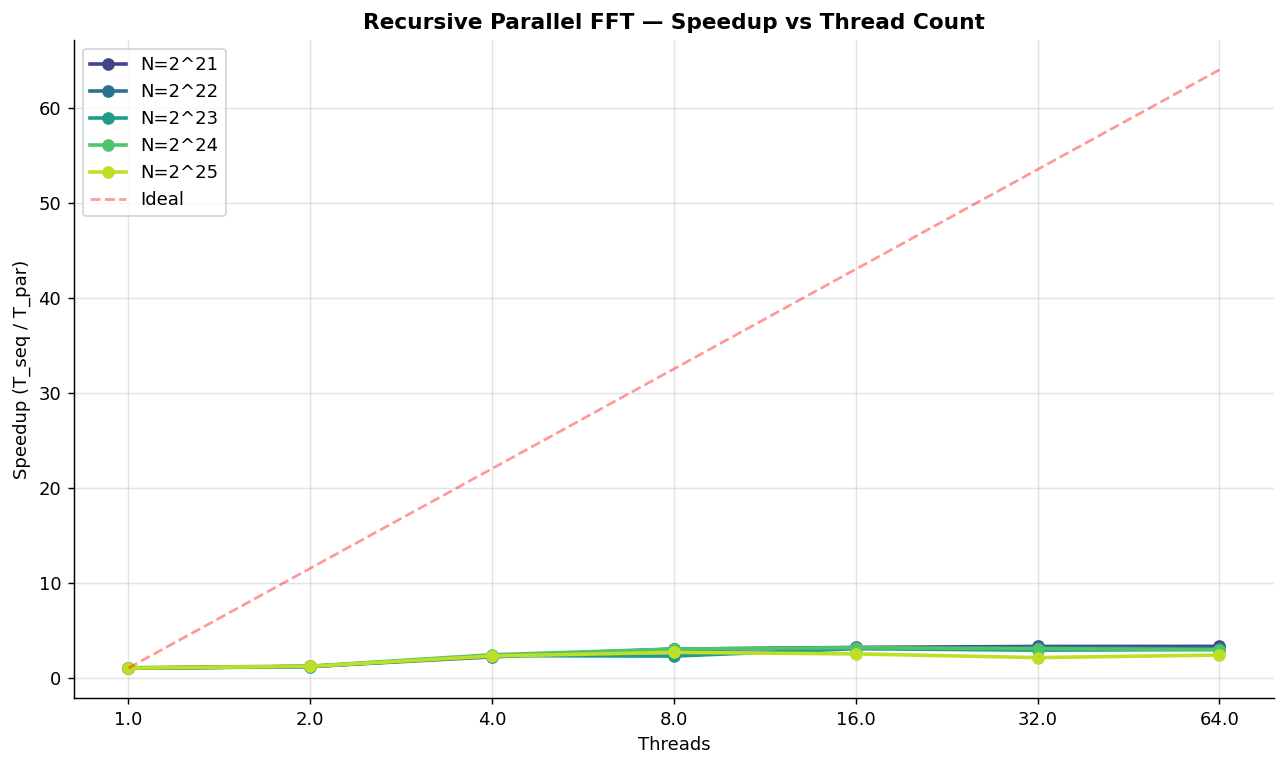

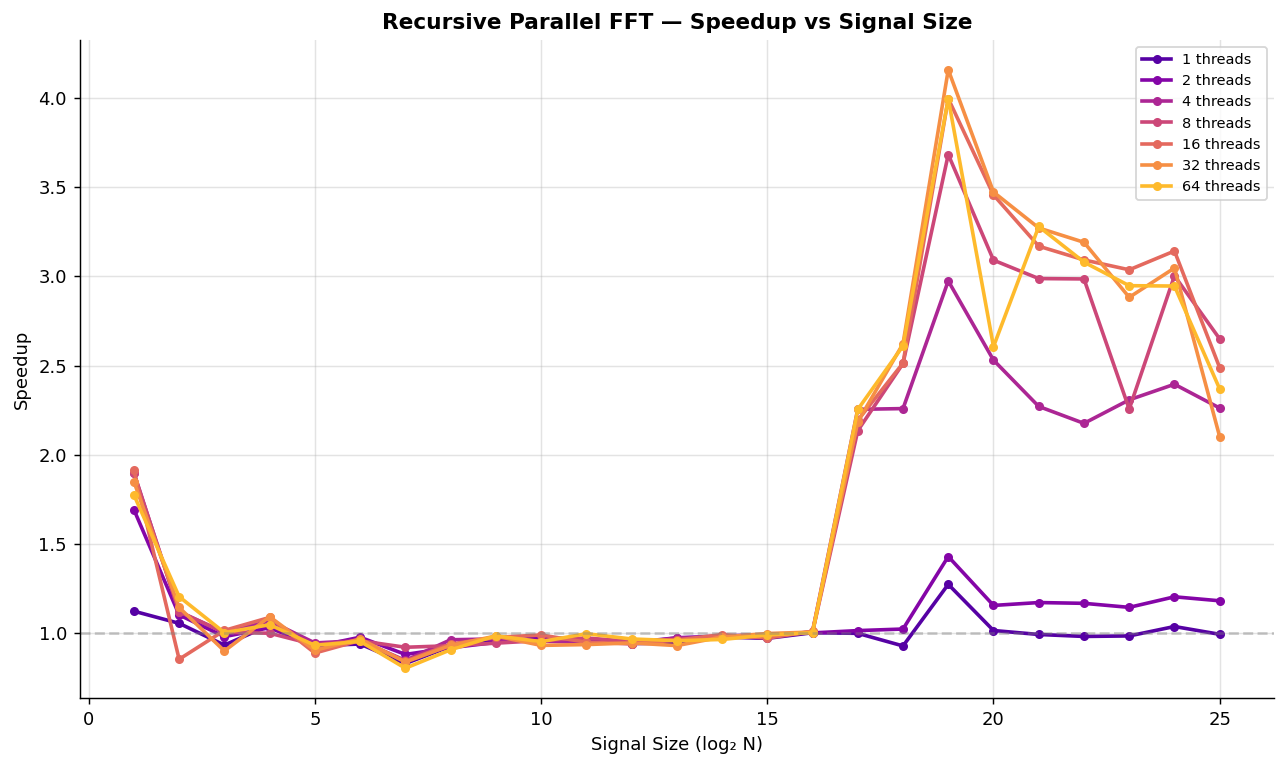

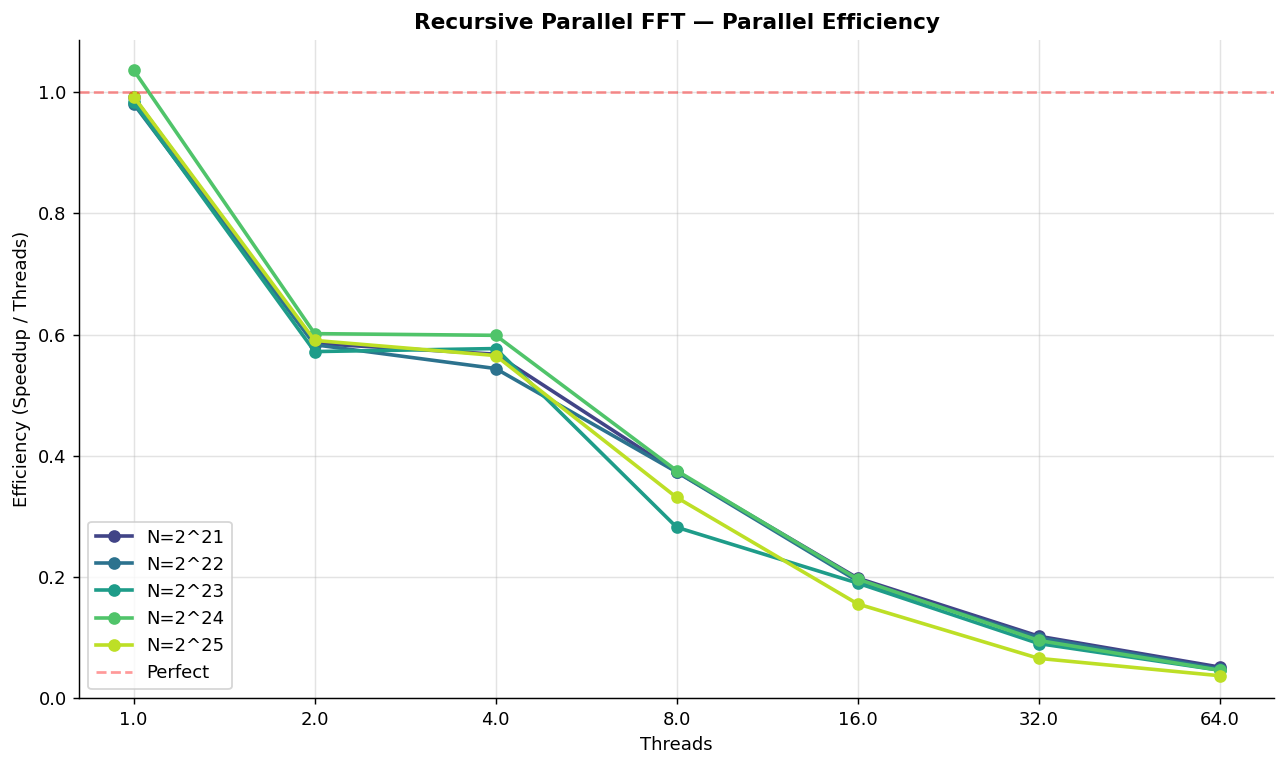

In [13]:
# Plot 1: Speedup vs Threads (large sizes)
seq_baseline = load_csv_sequential(SEQ_REC_CSV)
par_data     = load_csv_parallel(REC_PAR_CSV)
overlap     = sorted(s for s in set(k[1] for k in par_data) if s in seq_baseline)
all_threads = sorted(set(k[0] for k in par_data))

plot_sizes = overlap[-5:]   # 5 largest sizes
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(plot_sizes)))

fig, ax = plt.subplots(figsize=(10, 6))
for s, c in zip(plot_sizes, colors):
    p = int(math.log2(s))
    xs = [t for t in all_threads if (t,s) in par_data]
    ys = [seq_baseline[s] / par_data[(t,s)] for t in xs]
    ax.plot(xs, ys, 'o-', color=c, linewidth=2, markersize=6, label=f'N=2^{p}')
ax.plot([1, max(all_threads)], [1, max(all_threads)], '--', color='red', alpha=0.4, linewidth=1.5, label='Ideal')
ax.set_xscale('log', base=2); ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xlabel('Threads'); ax.set_ylabel('Speedup (T_seq / T_par)')
ax.set_title('Recursive Parallel FFT — Speedup vs Thread Count', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

# Plot 2: Speedup vs Size (per thread count)
fig, ax = plt.subplots(figsize=(10, 6))
colors2 = plt.cm.plasma(np.linspace(0.15, 0.85, len(all_threads)))
for t, c in zip(all_threads, colors2):
    xs = [int(math.log2(s)) for s in overlap if (t,s) in par_data]
    ys = [seq_baseline[s] / par_data[(t,s)] for s in overlap if (t,s) in par_data]
    ax.plot(xs, ys, 'o-', color=c, linewidth=2, markersize=4, label=f'{t} threads')
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.4)
ax.set_xlabel('Signal Size (log₂ N)'); ax.set_ylabel('Speedup')
ax.set_title('Recursive Parallel FFT — Speedup vs Signal Size', fontweight='bold')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

# Plot 3: Parallel Efficiency
fig, ax = plt.subplots(figsize=(10, 6))
for s, c in zip(plot_sizes, colors):
    p = int(math.log2(s))
    xs = [t for t in all_threads if (t,s) in par_data]
    ys = [(seq_baseline[s] / par_data[(t,s)]) / t for t in xs]
    ax.plot(xs, ys, 'o-', color=c, linewidth=2, markersize=6, label=f'N=2^{p}')
ax.axhline(1.0, color='red', linestyle='--', alpha=0.4, label='Perfect')
ax.set_xscale('log', base=2); ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xlabel('Threads'); ax.set_ylabel('Efficiency (Speedup / Threads)')
ax.set_title('Recursive Parallel FFT — Parallel Efficiency', fontweight='bold')
ax.set_ylim(bottom=0); ax.legend(); plt.tight_layout(); plt.show()


# Iterative Parallel 

In [32]:
IT_PAR_CPP    = "../src/cooley_tukey_iterative_parallel.cpp"  # ← update path if needed
IT_PAR_BIN    = "./bin_it_par"
IT_PAR_CSV    = "iter_parallel.csv"
IT_PAR_FLAGS  = ["-O2", "-std=c++17", "-pthread"]
IT_PAR_RUNS   = 20
IT_PAR_SIZES   = [2**p for p in range(1, 26)]   # 2^1 … 2^20
IT_PAR_THREADS = [2**p for p in range(0, 7)]    # 1, 2, 4, 8, 16, 32, 64

In [33]:
compile_cpp(IT_PAR_CPP, IT_PAR_BIN, IT_PAR_FLAGS)

it_par_results = []
total = len(IT_PAR_SIZES) * len(IT_PAR_THREADS)
done  = 0
t0    = time.time()

for length in IT_PAR_SIZES:
    for threads in IT_PAR_THREADS:
        done += 1
        r = benchmark_parallel(IT_PAR_BIN, threads, length, IT_PAR_RUNS)
        it_par_results.append(r)
        avg_str = f"{r['avg']:.6f}s (ok={r['valid']}/{IT_PAR_RUNS})" if r['avg'] else "FAILED"
        power = int(math.log2(length))
        print(f"[{done:>3}/{total}] N=2^{power:<2} T={threads:<3} | avg={avg_str}")

print(f"\nDone in {time.time()-t0:.1f}s")
save_csv_parallel(it_par_results, IT_PAR_CSV)

Compiling: g++ ../src/cooley_tukey_iterative_parallel.cpp -o ./bin_it_par -O2 -std=c++17 -pthread
[OK] Compiled

[  1/175] N=2^1  T=1   | avg=0.000027s (ok=20/20)
[  2/175] N=2^1  T=2   | avg=0.000028s (ok=20/20)
[  3/175] N=2^1  T=4   | avg=0.000045s (ok=20/20)
[  4/175] N=2^1  T=8   | avg=0.000110s (ok=20/20)
[  5/175] N=2^1  T=16  | avg=0.000197s (ok=20/20)
[  6/175] N=2^1  T=32  | avg=0.000402s (ok=20/20)
[  7/175] N=2^1  T=64  | avg=0.000687s (ok=20/20)
[  8/175] N=2^2  T=1   | avg=0.000017s (ok=20/20)
[  9/175] N=2^2  T=2   | avg=0.000029s (ok=20/20)
[ 10/175] N=2^2  T=4   | avg=0.000047s (ok=20/20)
[ 11/175] N=2^2  T=8   | avg=0.000109s (ok=20/20)
[ 12/175] N=2^2  T=16  | avg=0.000227s (ok=20/20)
[ 13/175] N=2^2  T=32  | avg=0.000427s (ok=20/20)
[ 14/175] N=2^2  T=64  | avg=0.000686s (ok=20/20)
[ 15/175] N=2^3  T=1   | avg=0.000015s (ok=20/20)
[ 16/175] N=2^3  T=2   | avg=0.000033s (ok=20/20)
[ 17/175] N=2^3  T=4   | avg=0.000050s (ok=20/20)
[ 18/175] N=2^3  T=8   | avg=0.000119

In [34]:
# ── Iterative Parallel Speedup Analysis ───────────────────
seq_baseline = load_csv_sequential(SEQ_IT_CSV)   # sequential iterative as baseline
par_data     = load_csv_parallel(IT_PAR_CSV)

overlap     = sorted(s for s in set(k[1] for k in par_data) if s in seq_baseline)
all_threads = sorted(set(k[0] for k in par_data))

print("=" * 90)
print("ITERATIVE PARALLEL — Speedup vs Sequential Iterative")
print("=" * 90)

for t in all_threads:
    print(f"\n{'  THREADS: ' + str(t) + '  ':=^90}")
    print(f"{'Signal Size':>15} | {'Power':>5} | {'Seq Time':>12} | {'Par Time':>12} | {'Speedup':>10}")
    print("-" * 90)
    for s in overlap:
        if (t, s) in par_data:
            sp = seq_baseline[s] / par_data[(t, s)]
            print(f"{s:>15} | {int(math.log2(s)):>5} | {seq_baseline[s]:>12.6e} | {par_data[(t,s)]:>12.6e} | {sp:>10.4f}x")
print("\n" + "=" * 90)

ITERATIVE PARALLEL — Speedup vs Sequential Iterative

======================================  THREADS: 1  ======================================
    Signal Size | Power |     Seq Time |     Par Time |    Speedup
------------------------------------------------------------------------------------------
              2 |     1 | 4.103500e-07 | 2.655000e-05 |     0.0155x
              4 |     2 | 5.292000e-07 | 1.725000e-05 |     0.0307x
              8 |     3 | 1.060450e-06 | 1.500000e-05 |     0.0707x
             16 |     4 | 1.693950e-06 | 1.655000e-05 |     0.1024x
             32 |     5 | 3.058350e-06 | 1.655000e-05 |     0.1848x
             64 |     6 | 5.550000e-06 | 1.835000e-05 |     0.3025x
            128 |     7 | 1.082695e-05 | 1.810000e-05 |     0.5982x
            256 |     8 | 2.449595e-05 | 2.025000e-05 |     1.2097x
            512 |     9 | 4.550215e-05 | 2.465000e-05 |     1.8459x
           1024 |    10 | 8.963545e-05 | 2.960000e-05 |     3.0282x
           2048 |

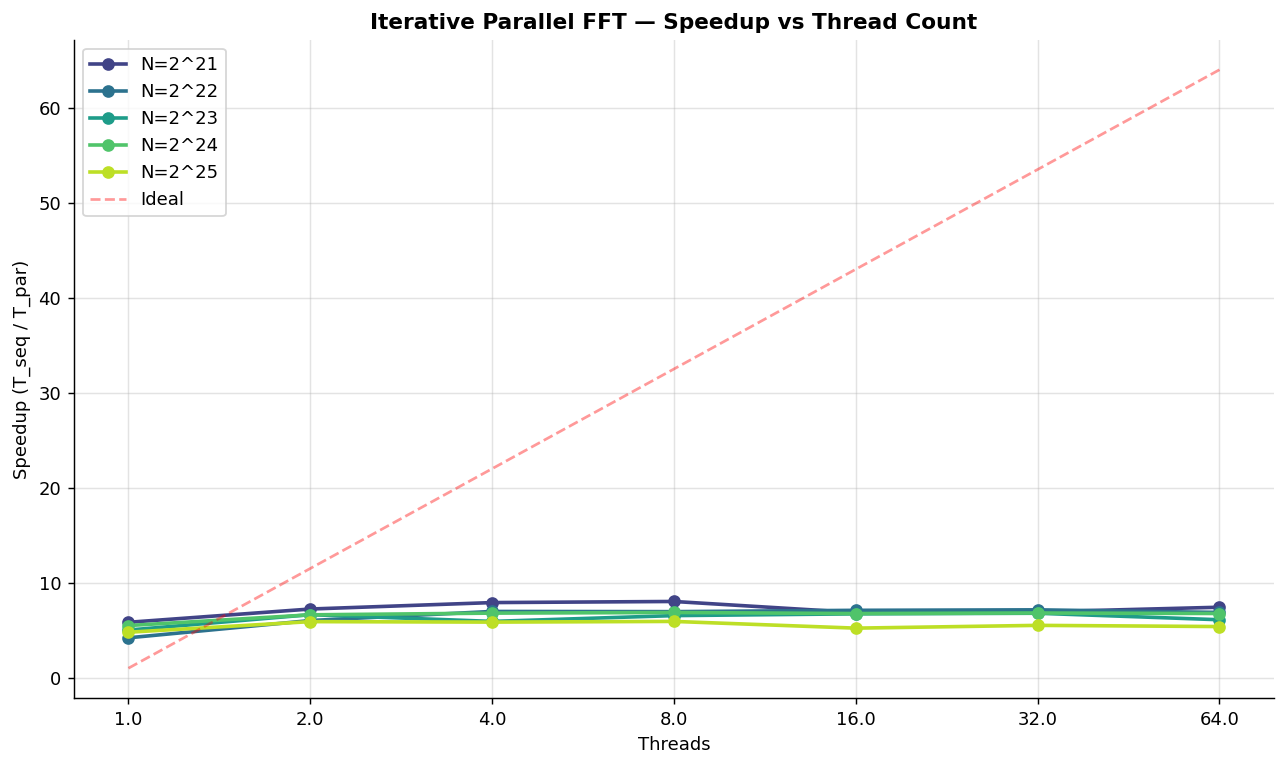

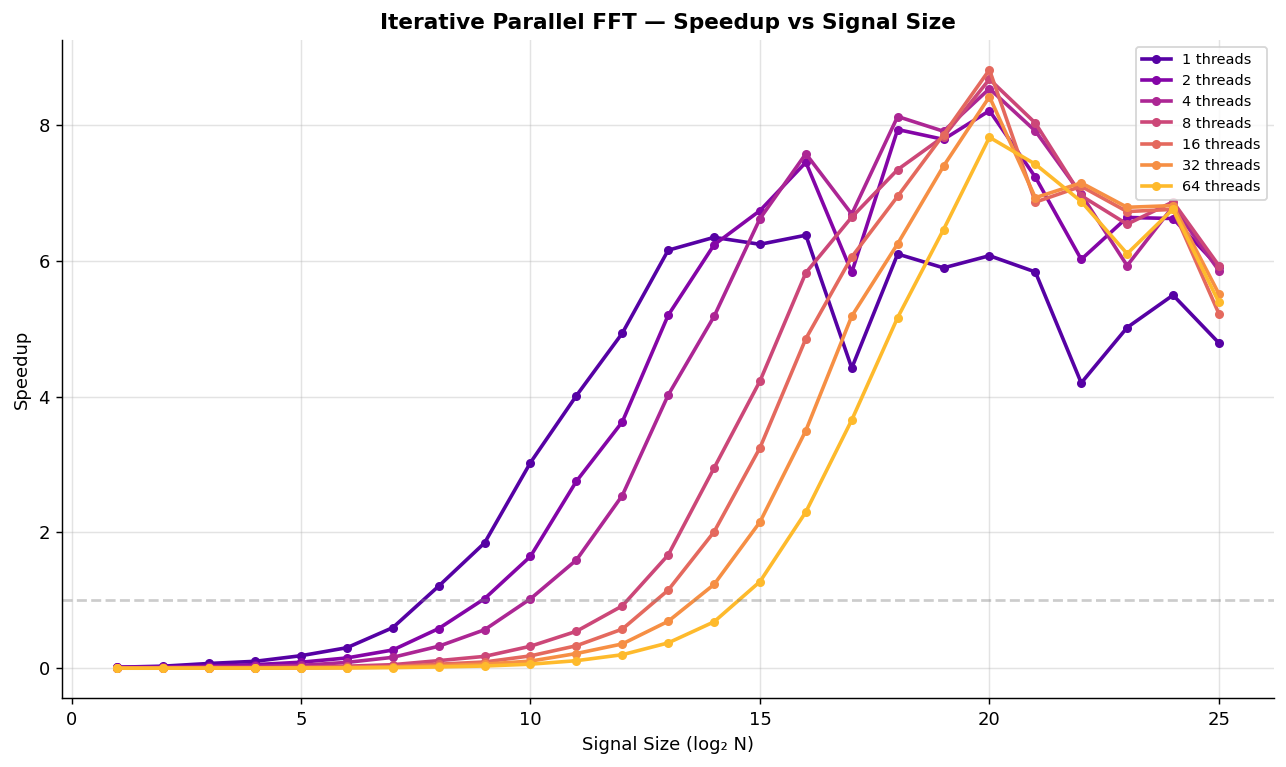

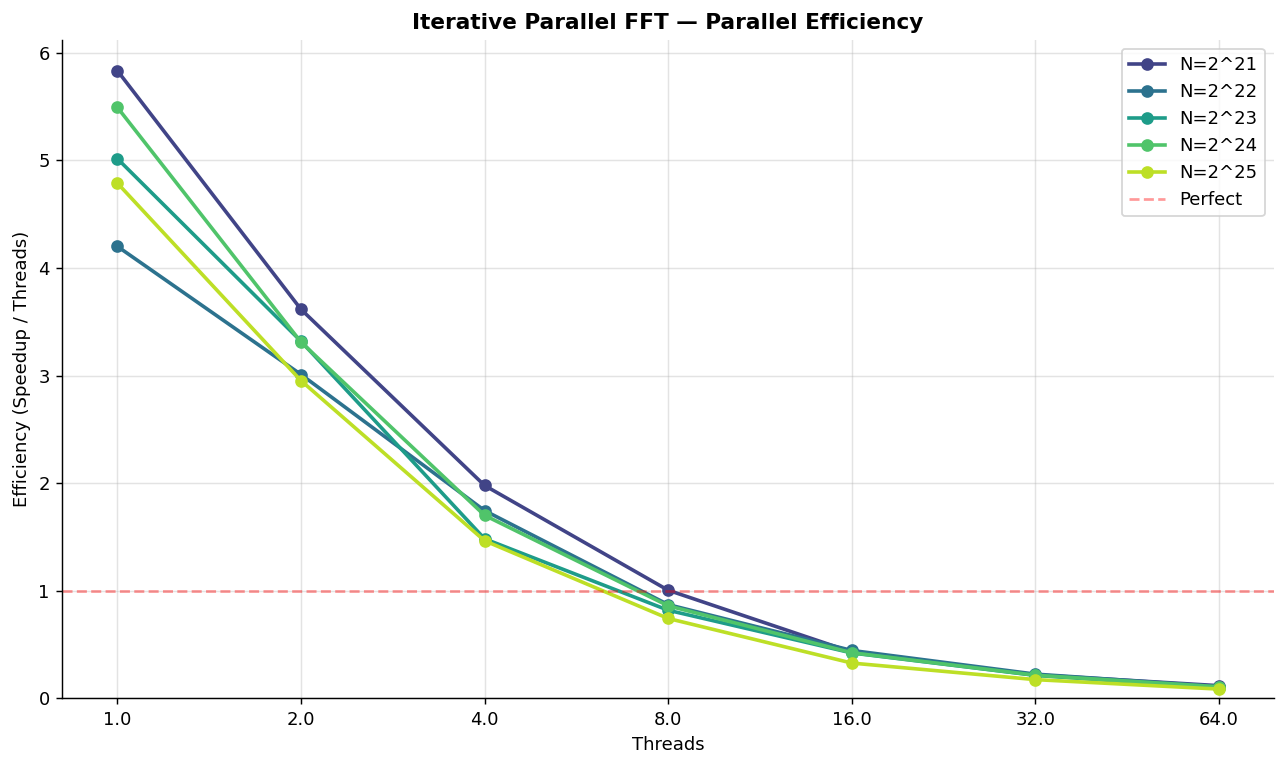

In [35]:
# Plot 1: Speedup vs Threads (large sizes)
seq_baseline = load_csv_sequential(SEQ_IT_CSV)
par_data     = load_csv_parallel(IT_PAR_CSV)
overlap     = sorted(s for s in set(k[1] for k in par_data) if s in seq_baseline)
all_threads = sorted(set(k[0] for k in par_data))

plot_sizes = overlap[-5:]
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(plot_sizes)))

fig, ax = plt.subplots(figsize=(10, 6))
for s, c in zip(plot_sizes, colors):
    p = int(math.log2(s))
    xs = [t for t in all_threads if (t,s) in par_data]
    ys = [seq_baseline[s] / par_data[(t,s)] for t in xs]
    ax.plot(xs, ys, 'o-', color=c, linewidth=2, markersize=6, label=f'N=2^{p}')
ax.plot([1, max(all_threads)], [1, max(all_threads)], '--', color='red', alpha=0.4, linewidth=1.5, label='Ideal')
ax.set_xscale('log', base=2); ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xlabel('Threads'); ax.set_ylabel('Speedup (T_seq / T_par)')
ax.set_title('Iterative Parallel FFT — Speedup vs Thread Count', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

# Plot 2: Speedup vs Size (per thread count)
fig, ax = plt.subplots(figsize=(10, 6))
colors2 = plt.cm.plasma(np.linspace(0.15, 0.85, len(all_threads)))
for t, c in zip(all_threads, colors2):
    xs = [int(math.log2(s)) for s in overlap if (t,s) in par_data]
    ys = [seq_baseline[s] / par_data[(t,s)] for s in overlap if (t,s) in par_data]
    ax.plot(xs, ys, 'o-', color=c, linewidth=2, markersize=4, label=f'{t} threads')
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.4)
ax.set_xlabel('Signal Size (log₂ N)'); ax.set_ylabel('Speedup')
ax.set_title('Iterative Parallel FFT — Speedup vs Signal Size', fontweight='bold')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

# Plot 3: Parallel Efficiency
fig, ax = plt.subplots(figsize=(10, 6))
for s, c in zip(plot_sizes, colors):
    p = int(math.log2(s))
    xs = [t for t in all_threads if (t,s) in par_data]
    ys = [(seq_baseline[s] / par_data[(t,s)]) / t for t in xs]
    ax.plot(xs, ys, 'o-', color=c, linewidth=2, markersize=6, label=f'N=2^{p}')
ax.axhline(1.0, color='red', linestyle='--', alpha=0.4, label='Perfect')
ax.set_xscale('log', base=2); ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xlabel('Threads'); ax.set_ylabel('Efficiency (Speedup / Threads)')
ax.set_title('Iterative Parallel FFT — Parallel Efficiency', fontweight='bold')
ax.set_ylim(bottom=0); ax.legend(); plt.tight_layout(); plt.show()

In [36]:
import csv
import math

# ── Load ──────────────────────────────────────────────────
seq_data = {}
with open("seq_recursive.csv") as f:
    for row in csv.DictReader(f):
        if row["avg"] not in ("", "None"):
            seq_data[int(row["length"])] = float(row["avg"])

par_data = {}
with open("iter_parallel.csv") as f:
    for row in csv.DictReader(f):
        if row["avg"] not in ("", "None", "nan"):
            par_data[(int(row["threads"]), int(row["length"]))] = float(row["avg"])

overlap     = sorted(s for s in set(k[1] for k in par_data) if s in seq_data)
all_threads = sorted(set(k[0] for k in par_data))

# ── Print ─────────────────────────────────────────────────
print("=" * 90)
print("SPEEDUP: Sequential Recursive  →  Iterative Parallel")
print("=" * 90)

for t in all_threads:
    print(f"\n{'  THREADS: ' + str(t) + '  ':=^90}")
    print(f"{'Signal Size':>15} | {'Power':>5} | {'Seq-Rec Time':>14} | {'Iter-Par Time':>14} | {'Speedup':>10}")
    print("-" * 90)
    for s in overlap:
        if (t, s) in par_data:
            sp = seq_data[s] / par_data[(t, s)]
            print(f"{s:>15} | {int(math.log2(s)):>5} | "
                  f"{seq_data[s]:>14.6e} | {par_data[(t,s)]:>14.6e} | {sp:>10.4f}x")

print("\n" + "=" * 90)

SPEEDUP: Sequential Recursive  →  Iterative Parallel

======================================  THREADS: 1  ======================================
    Signal Size | Power |   Seq-Rec Time |  Iter-Par Time |    Speedup
------------------------------------------------------------------------------------------
              2 |     1 |   4.584000e-07 |   2.655000e-05 |     0.0173x
              4 |     2 |   5.668500e-07 |   1.725000e-05 |     0.0329x
              8 |     3 |   1.006200e-06 |   1.500000e-05 |     0.0671x
             16 |     4 |   1.735500e-06 |   1.655000e-05 |     0.1049x
             32 |     5 |   2.756250e-06 |   1.655000e-05 |     0.1665x
             64 |     6 |   5.295800e-06 |   1.835000e-05 |     0.2886x
            128 |     7 |   1.039790e-05 |   1.810000e-05 |     0.5745x
            256 |     8 |   2.346040e-05 |   2.025000e-05 |     1.1585x
            512 |     9 |   4.313125e-05 |   2.465000e-05 |     1.7497x
           1024 |    10 |   8.062275e-05 |   

# Bailey Sequential

In [19]:
SEQ_IT_CPP    = "/Users/yashwanth/Desktop/IITH/SEM 6/PCP/project/Project/src/bailey_sequential.cpp"  # ← update path if needed
SEQ_IT_BIN    = "./bin_seq_bailey"
SEQ_IT_CSV    = "seq_bailey.csv"
SEQ_IT_FLAGS  = ["-O2", "-std=c++17"]
SEQ_IT_RUNS   = 20
SEQ_IT_SIZES  = [2**p for p in range(1, 26)]   # 2^1 … 2^20

In [20]:
compile_cpp(SEQ_REC_CPP, SEQ_REC_BIN, SEQ_REC_FLAGS)

seq_bailey_results = []
t0 = time.time()
for i, length in enumerate(SEQ_REC_SIZES, 1):
    r = benchmark_sequential(SEQ_REC_BIN, length, SEQ_REC_RUNS)
    seq_bailey_results.append(r)
    avg_str = f"{r['avg']:.6f}s" if r['avg'] else "FAILED"
    print(f"[{i:>2}/{len(SEQ_REC_SIZES)}] N=2^{int(math.log2(length)):<2} ({length:<8}) avg={avg_str}")

print(f"\nDone in {time.time()-t0:.1f}s")
save_csv_sequential(seq_bailey_results, SEQ_IT_CSV)

Compiling: g++ ../src/cooley_tukey_sequential.cpp -o ./bin_seq_rec -O2 -std=c++17
[OK] Compiled

[ 1/25] N=2^1  (2       ) avg=0.000000s
[ 2/25] N=2^2  (4       ) avg=0.000001s
[ 3/25] N=2^3  (8       ) avg=0.000001s
[ 4/25] N=2^4  (16      ) avg=0.000002s
[ 5/25] N=2^5  (32      ) avg=0.000003s
[ 6/25] N=2^6  (64      ) avg=0.000006s
[ 7/25] N=2^7  (128     ) avg=0.000011s
[ 8/25] N=2^8  (256     ) avg=0.000024s
[ 9/25] N=2^9  (512     ) avg=0.000046s
[10/25] N=2^10 (1024    ) avg=0.000090s
[11/25] N=2^11 (2048    ) avg=0.000173s
[12/25] N=2^12 (4096    ) avg=0.000331s
[13/25] N=2^13 (8192    ) avg=0.000682s
[14/25] N=2^14 (16384   ) avg=0.001360s
[15/25] N=2^15 (32768   ) avg=0.002791s
[16/25] N=2^16 (65536   ) avg=0.005800s
[17/25] N=2^17 (131072  ) avg=0.012072s
[18/25] N=2^18 (262144  ) avg=0.024558s
[19/25] N=2^19 (524288  ) avg=0.050560s
[20/25] N=2^20 (1048576 ) avg=0.106314s
[21/25] N=2^21 (2097152 ) avg=0.215565s
[22/25] N=2^22 (4194304 ) avg=0.442747s
[23/25] N=2^23 (8388608

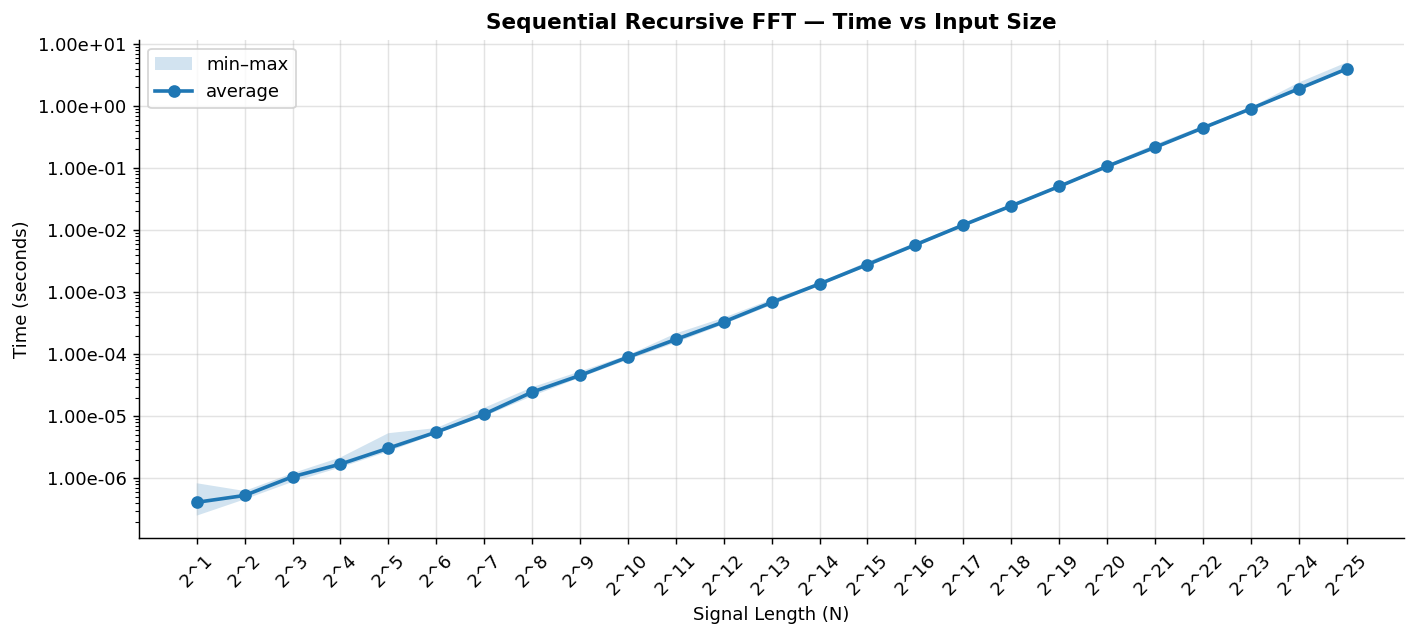

In [21]:
# Plot: Sequential Recursive — Time vs Signal Size
rows = [r for r in seq_bailey_results if r['avg'] is not None]
xi   = list(range(len(rows)))
xlabs = [f"2^{int(math.log2(r['length']))}" for r in rows]

fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(xi, [r['min'] for r in rows], [r['max'] for r in rows], alpha=0.2, label='min–max')
ax.plot(xi, [r['avg'] for r in rows], 'o-', linewidth=2, label='average')
ax.set_xticks(xi); ax.set_xticklabels(xlabs, rotation=45)
ax.set_xlabel('Signal Length (N)'); ax.set_ylabel('Time (seconds)')
ax.set_title('Sequential Recursive FFT — Time vs Input Size', fontweight='bold')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2e'))
ax.legend(); plt.tight_layout(); plt.show()

# Bailey Parallel

In [44]:
IT_PAR_CPP    = "/Users/yashwanth/Desktop/IITH/SEM 6/PCP/project/Project/src/bailey_parallel.cpp"  # ← update path if needed
IT_PAR_BIN    = "./bin_bailey_par"
IT_PAR_CSV    = "bailey_parallel.csv"
IT_PAR_FLAGS  = ["-O2", "-std=c++17", "-pthread"]
IT_PAR_RUNS   = 20
IT_PAR_SIZES   = [2**p for p in range(1, 26)]   # 2^1 … 2^20
IT_PAR_THREADS = [2**p for p in range(0, 7)]    # 1, 2, 4, 8, 16, 32, 64

In [45]:
compile_cpp(IT_PAR_CPP, IT_PAR_BIN, IT_PAR_FLAGS)

bailey_par_results = []
total = len(IT_PAR_SIZES) * len(IT_PAR_THREADS)
done  = 0
t0    = time.time()

for length in IT_PAR_SIZES:
    for threads in IT_PAR_THREADS:
        done += 1
        r = benchmark_parallel(IT_PAR_BIN, threads, length, IT_PAR_RUNS)
        bailey_par_results.append(r)
        avg_str = f"{r['avg']:.6f}s (ok={r['valid']}/{IT_PAR_RUNS})" if r['avg'] else "FAILED"
        power = int(math.log2(length))
        print(f"[{done:>3}/{total}] N=2^{power:<2} T={threads:<3} | avg={avg_str}")

print(f"\nDone in {time.time()-t0:.1f}s")
save_csv_parallel(bailey_par_results, IT_PAR_CSV)

Compiling: g++ /Users/yashwanth/Desktop/IITH/SEM 6/PCP/project/Project/src/bailey_parallel.cpp -o ./bin_bailey_par -O2 -std=c++17 -pthread
[OK] Compiled

[  1/175] N=2^1  T=1   | avg=0.000127s (ok=20/20)
[  2/175] N=2^1  T=2   | avg=0.000135s (ok=20/20)
[  3/175] N=2^1  T=4   | avg=0.000209s (ok=20/20)
[  4/175] N=2^1  T=8   | avg=0.000377s (ok=20/20)
[  5/175] N=2^1  T=16  | avg=0.000712s (ok=20/20)
[  6/175] N=2^1  T=32  | avg=0.001426s (ok=20/20)
[  7/175] N=2^1  T=64  | avg=0.002854s (ok=20/20)
[  8/175] N=2^2  T=1   | avg=0.000081s (ok=20/20)
[  9/175] N=2^2  T=2   | avg=0.000132s (ok=20/20)
[ 10/175] N=2^2  T=4   | avg=0.000212s (ok=20/20)
[ 11/175] N=2^2  T=8   | avg=0.000368s (ok=20/20)
[ 12/175] N=2^2  T=16  | avg=0.000737s (ok=20/20)
[ 13/175] N=2^2  T=32  | avg=0.001722s (ok=20/20)
[ 14/175] N=2^2  T=64  | avg=0.003120s (ok=20/20)
[ 15/175] N=2^3  T=1   | avg=0.000084s (ok=20/20)
[ 16/175] N=2^3  T=2   | avg=0.000146s (ok=20/20)
[ 17/175] N=2^3  T=4   | avg=0.000210s (ok=20/

In [46]:
import csv
import math

# ── Load ──────────────────────────────────────────────────
seq_data = {}
with open("/Users/yashwanth/Desktop/IITH/SEM 6/PCP/project/Project/src/seq_bailey.csv") as f:
    for row in csv.DictReader(f):
        if row["avg"] not in ("", "None"):
            seq_data[int(row["length"])] = float(row["avg"])

par_data = {}
with open("/Users/yashwanth/Desktop/IITH/SEM 6/PCP/project/Project/src/bailey_parallel.csv") as f:
    for row in csv.DictReader(f):
        if row["avg"] not in ("", "None", "nan"):
            par_data[(int(row["threads"]), int(row["length"]))] = float(row["avg"])

overlap     = sorted(s for s in set(k[1] for k in par_data) if s in seq_data)
all_threads = sorted(set(k[0] for k in par_data))

# ── Print ─────────────────────────────────────────────────
print("=" * 90)
print("SPEEDUP: Sequential Recursive  →  Iterative Parallel")
print("=" * 90)

for t in all_threads:
    print(f"\n{'  THREADS: ' + str(t) + '  ':=^90}")
    print(f"{'Signal Size':>15} | {'Power':>5} | {'Seq-Rec Time':>14} | {'Iter-Par Time':>14} | {'Speedup':>10}")
    print("-" * 90)
    for s in overlap:
        if (t, s) in par_data:
            sp = seq_data[s] / par_data[(t, s)]
            print(f"{s:>15} | {int(math.log2(s)):>5} | "
                  f"{seq_data[s]:>14.6e} | {par_data[(t,s)]:>14.6e} | {sp:>10.4f}x")

print("\n" + "=" * 90)

SPEEDUP: Sequential Recursive  →  Iterative Parallel

======================================  THREADS: 1  ======================================
    Signal Size | Power |   Seq-Rec Time |  Iter-Par Time |    Speedup
------------------------------------------------------------------------------------------
              2 |     1 |   4.103500e-07 |   1.265978e-04 |     0.0032x
              4 |     2 |   5.292000e-07 |   8.102310e-05 |     0.0065x
              8 |     3 |   1.060450e-06 |   8.417490e-05 |     0.0126x
             16 |     4 |   1.693950e-06 |   8.100225e-05 |     0.0209x
             32 |     5 |   3.058350e-06 |   8.738525e-05 |     0.0350x
             64 |     6 |   5.550000e-06 |   1.013062e-04 |     0.0548x
            128 |     7 |   1.082695e-05 |   9.424380e-05 |     0.1149x
            256 |     8 |   2.449595e-05 |   1.081251e-04 |     0.2266x
            512 |     9 |   4.550215e-05 |   1.081188e-04 |     0.4209x
           1024 |    10 |   8.963545e-05 |   

# FFTW

In [25]:
FFTW_PAR_CPP    = "../src/fftw.cpp"
FFTW_PAR_BIN    = "./bin_fftw_par"
FFTW_PAR_CSV    = "fftw_parallel.csv"

FFTW_PAR_FLAGS  = [
    "-O3", "-std=c++17",
    "-I/opt/homebrew/include", "-L/opt/homebrew/lib",
    "-lfftw3_threads", "-lfftw3", "-lm", "-lpthread"
]
FFTW_PAR_RUNS    = 20
FFTW_PAR_SIZES   = [2**p for p in range(1, 26)]
FFTW_PAR_THREADS = [1, 2, 4, 8, 16, 32, 64]

compile_cpp(FFTW_PAR_CPP, FFTW_PAR_BIN, FFTW_PAR_FLAGS)

fftw_par_results = []
total = len(FFTW_PAR_SIZES) * len(FFTW_PAR_THREADS)
done  = 0
t0    = time.time()

for length in FFTW_PAR_SIZES:
    for t in FFTW_PAR_THREADS:
        done += 1
        r = benchmark_parallel(FFTW_PAR_BIN, t, length, FFTW_PAR_RUNS)  # ← fixed order
        fftw_par_results.append(r)
        avg_str = f"{r['avg']:.6f}s" if r['avg'] else "FAILED"
        print(f"[{done:>4}/{total}] N=2^{int(math.log2(length)):<2} T={t:<3} → {avg_str}")

print(f"\nDone in {time.time()-t0:.1f}s")
save_csv_parallel(fftw_par_results, FFTW_PAR_CSV)

Compiling: g++ ../src/fftw.cpp -o ./bin_fftw_par -O3 -std=c++17 -I/opt/homebrew/include -L/opt/homebrew/lib -lfftw3_threads -lfftw3 -lm -lpthread
[OK] Compiled

[   1/175] N=2^1  T=1   → 0.000000s
[   2/175] N=2^1  T=2   → 0.000000s
[   3/175] N=2^1  T=4   → 0.000000s
[   4/175] N=2^1  T=8   → 0.000000s
[   5/175] N=2^1  T=16  → 0.000000s
[   6/175] N=2^1  T=32  → 0.000000s
[   7/175] N=2^1  T=64  → 0.000000s
[   8/175] N=2^2  T=1   → 0.000000s
[   9/175] N=2^2  T=2   → 0.000000s
[  10/175] N=2^2  T=4   → 0.000000s
[  11/175] N=2^2  T=8   → 0.000000s
[  12/175] N=2^2  T=16  → 0.000000s
[  13/175] N=2^2  T=32  → 0.000000s
[  14/175] N=2^2  T=64  → 0.000000s
[  15/175] N=2^3  T=1   → 0.000000s
[  16/175] N=2^3  T=2   → 0.000000s
[  17/175] N=2^3  T=4   → 0.000000s
[  18/175] N=2^3  T=8   → 0.000000s
[  19/175] N=2^3  T=16  → 0.000000s
[  20/175] N=2^3  T=32  → 0.000000s
[  21/175] N=2^3  T=64  → 0.000000s
[  22/175] N=2^4  T=1   → 0.000000s
[  23/175] N=2^4  T=2   → 0.000000s
[  24/175] 

# Comparsion

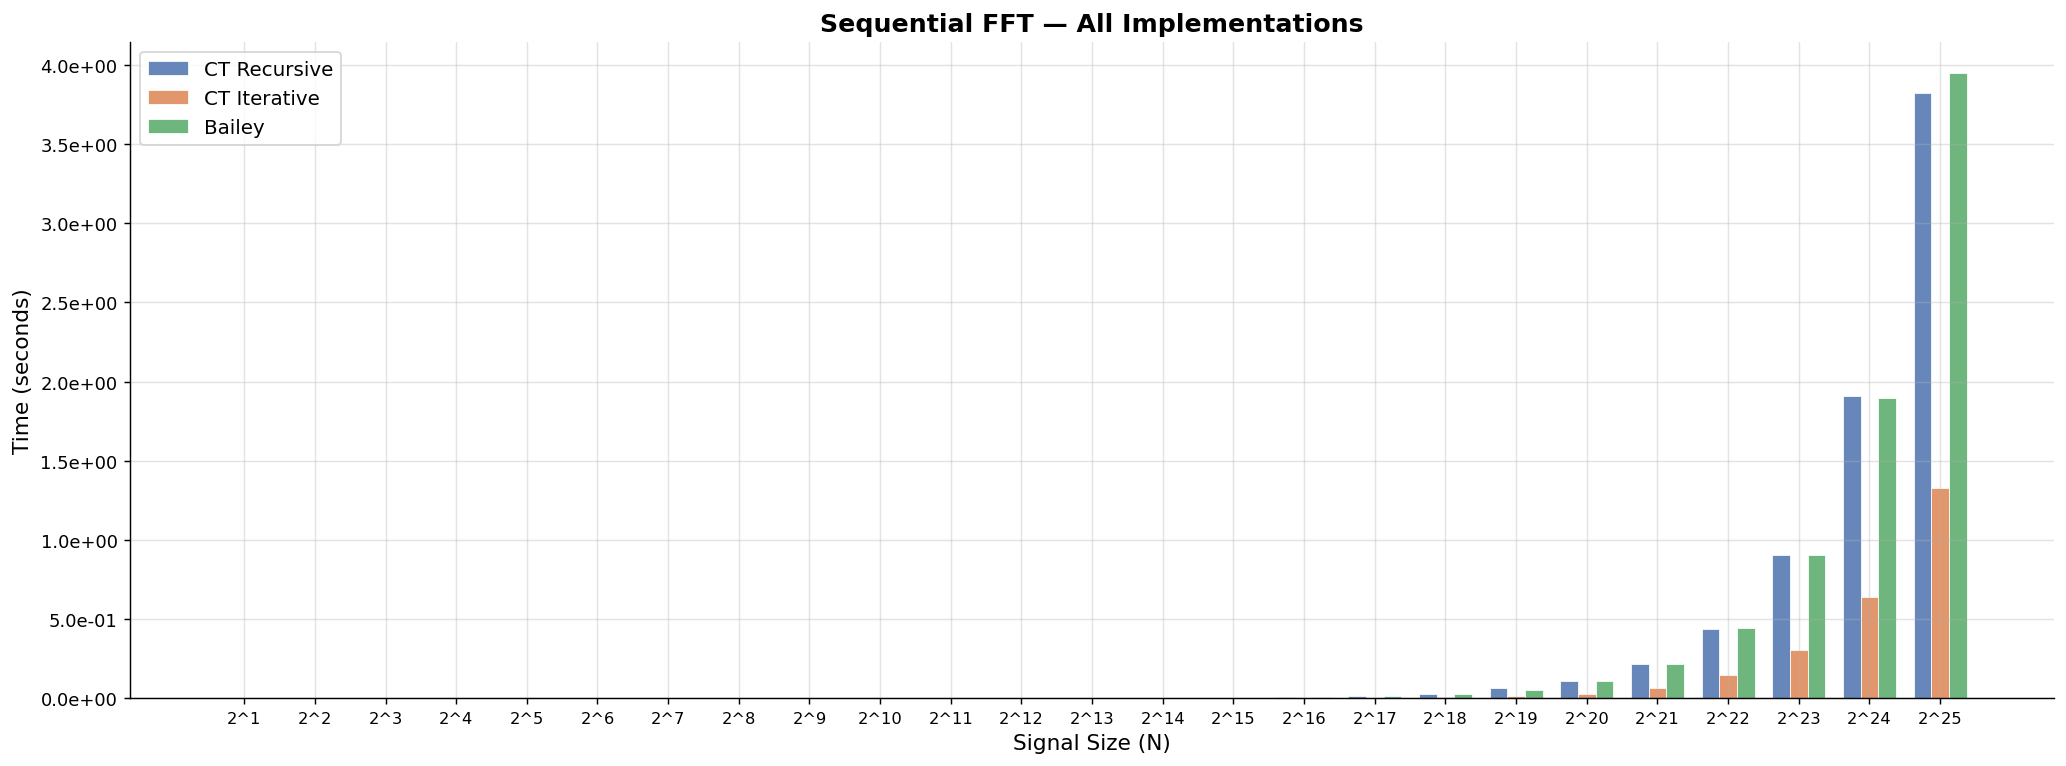

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

SIZES = [2**p for p in range(1, 26)]

# Load all 3 sequential CSVs
seq_rec  = load_csv_sequential("seq_recursive.csv")
seq_it   = load_csv_sequential("seq_iterative.csv")
seq_bail = load_csv_sequential("seq_bailey.csv")

seq_sources = {
    "CT Recursive":  seq_rec,
    "CT Iterative":  seq_it,
    "Bailey":        seq_bail,
}

valid_sizes = [n for n in SIZES if any(n in d for d in seq_sources.values())]
x       = np.arange(len(valid_sizes))
width   = 0.25
colors  = ["#4C72B0", "#DD8452", "#55A868"]

fig, ax = plt.subplots(figsize=(16, 6))
for i, (label, data) in enumerate(seq_sources.items()):
    vals   = [data.get(n, 0) for n in valid_sizes]
    offset = (i - 1) * width
    ax.bar(x + offset, vals, width, label=label, color=colors[i],
           alpha=0.85, edgecolor="white", linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels([f"2^{int(math.log2(n))}" for n in valid_sizes], fontsize=9)
ax.set_xlabel("Signal Size (N)", fontsize=12)
ax.set_ylabel("Time (seconds)", fontsize=12)
ax.set_title("Sequential FFT — All Implementations", fontsize=14, fontweight="bold")
ax.set_yscale("linear")
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1e"))
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig("compare_sequential.png", bbox_inches="tight", dpi=150)
plt.show()

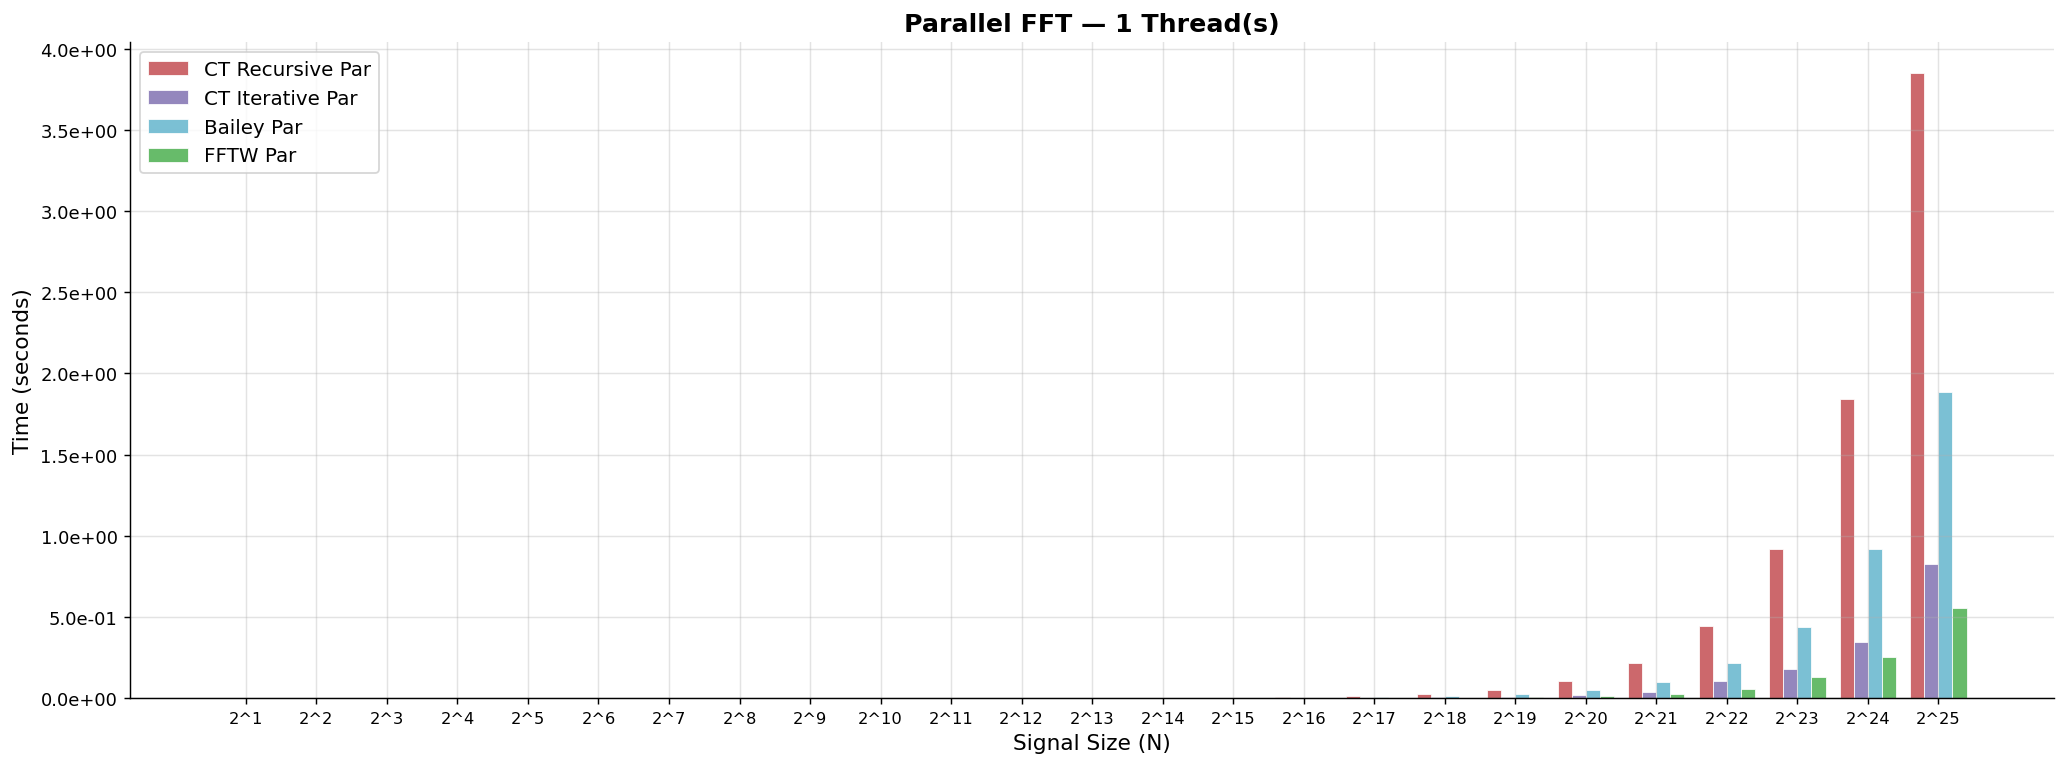

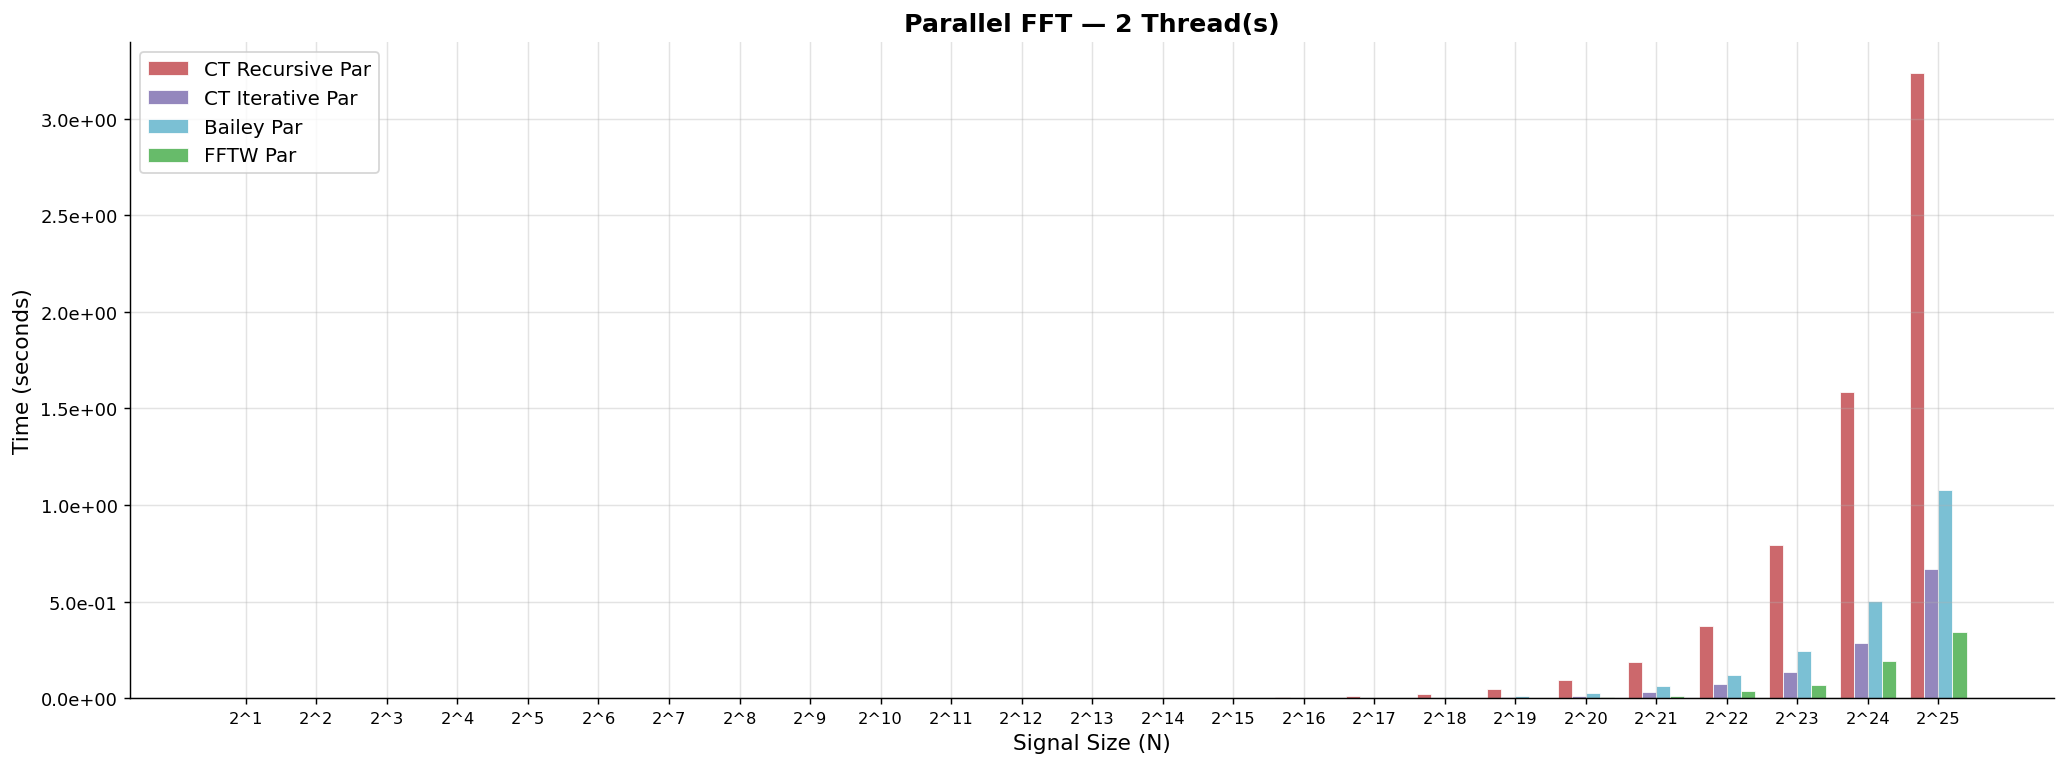

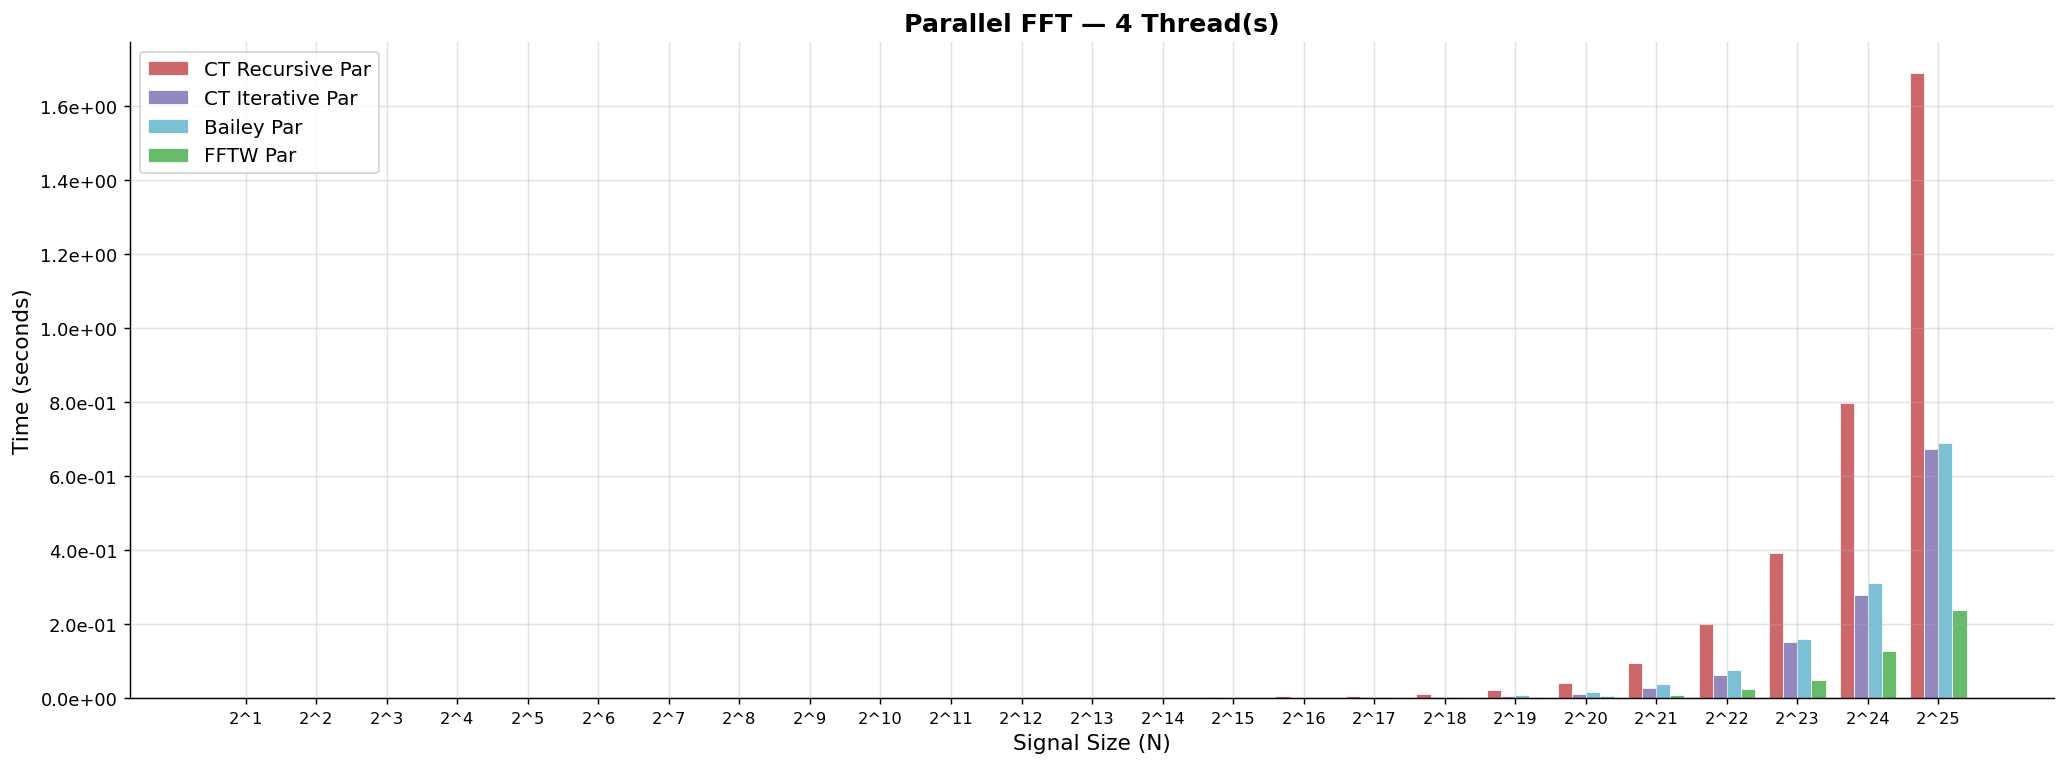

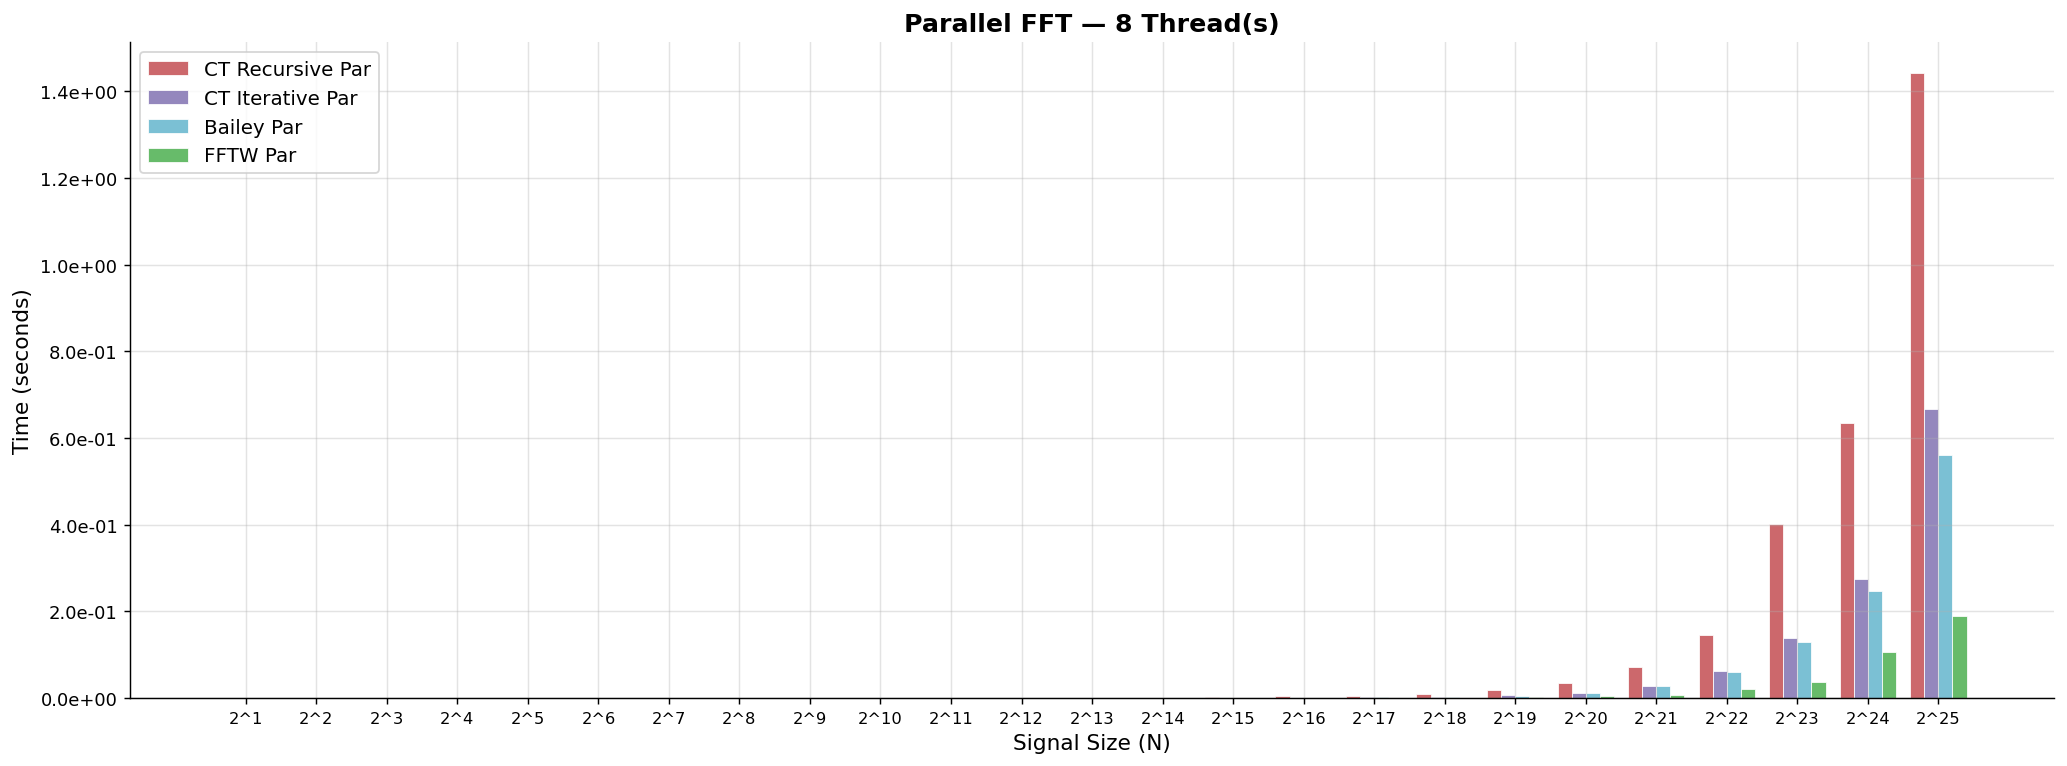

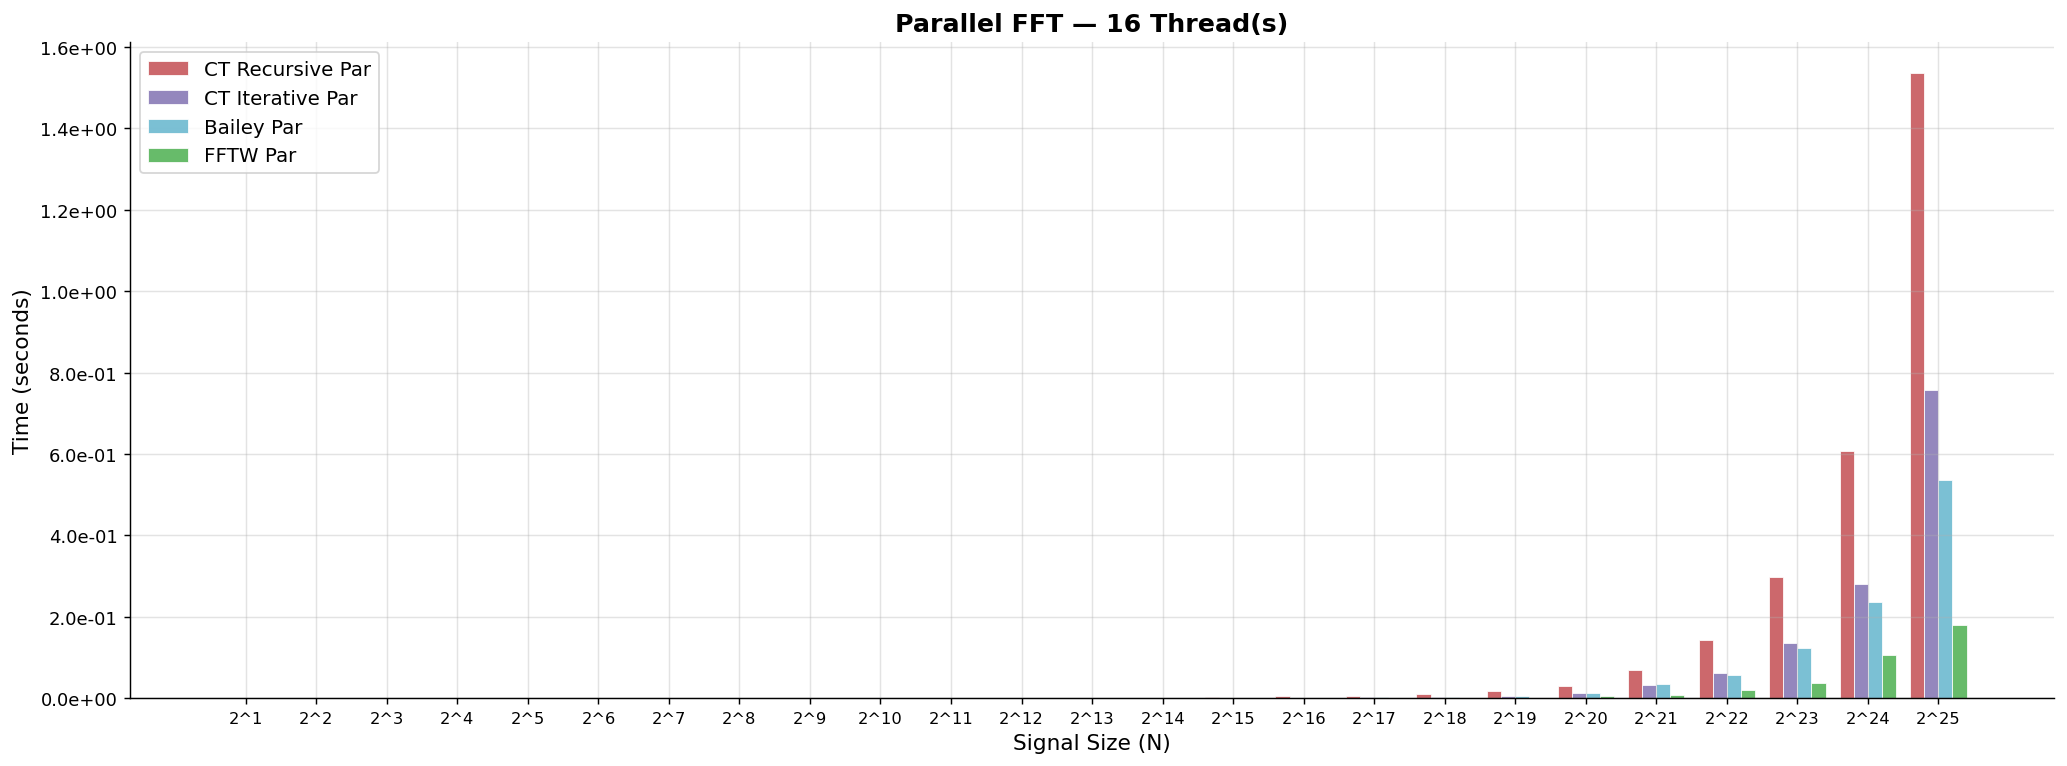

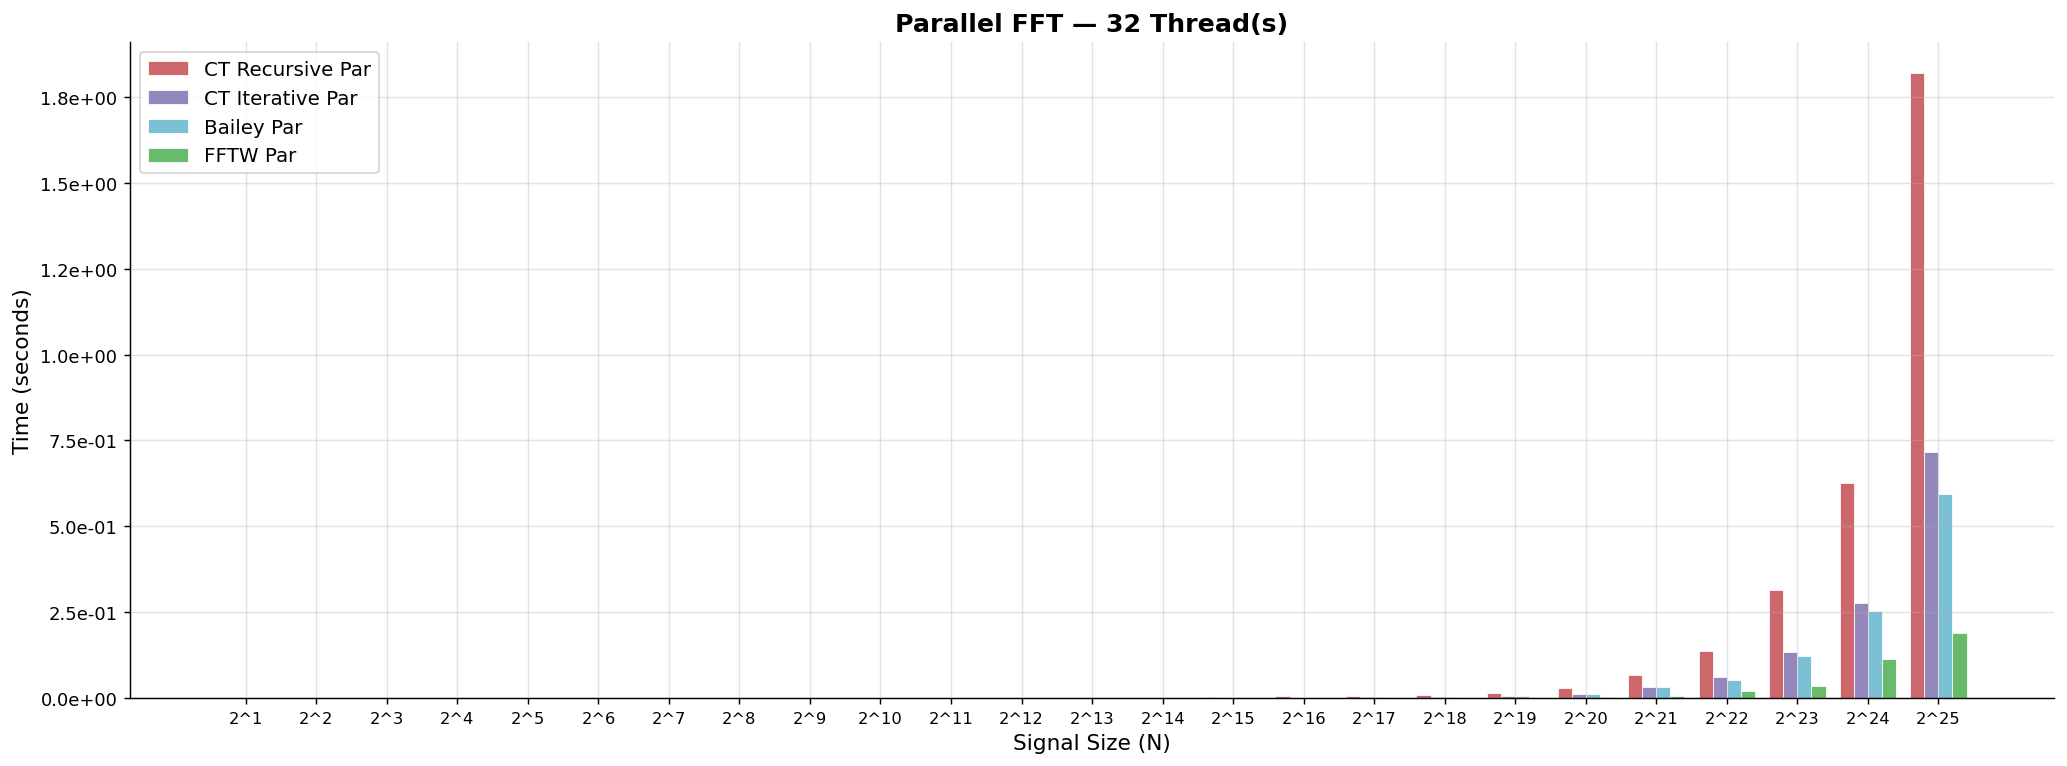

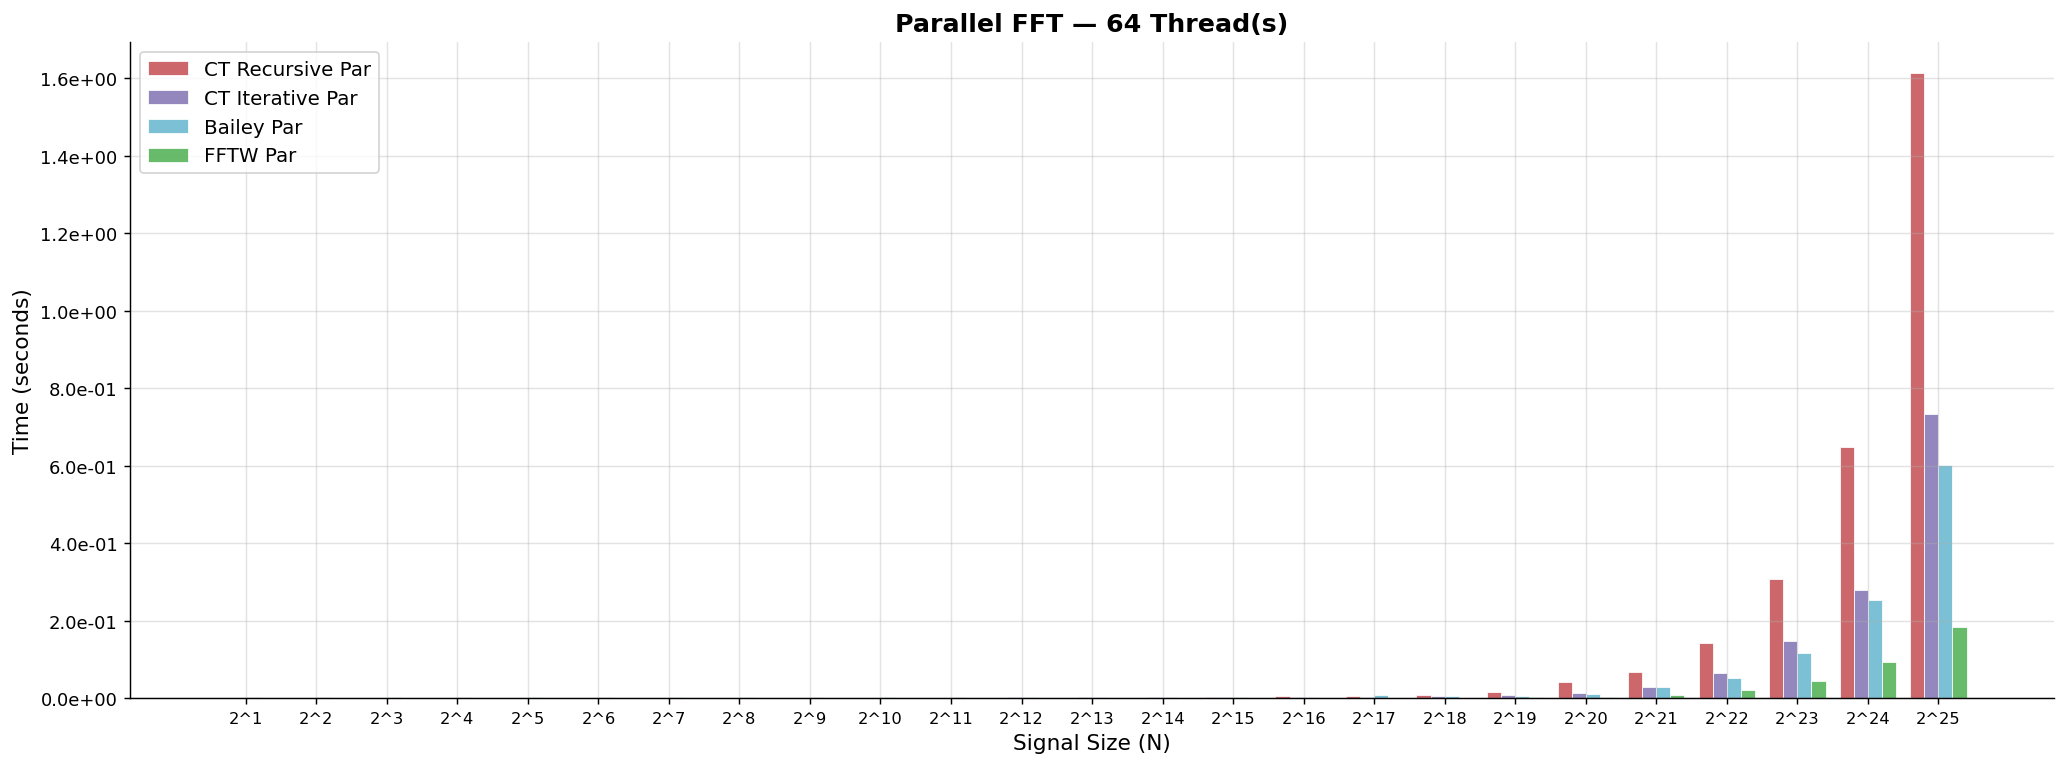

In [47]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

THREAD_COUNTS = [1, 2, 4, 8, 16, 32, 64]
SIZES         = [2**p for p in range(1, 26)]

# Assuming load_csv_parallel is defined and returns dicts mapped by (threads, size)
rec_par  = load_csv_parallel("rec_parallel.csv")
it_par   = load_csv_parallel("iter_parallel.csv")
bail_par = load_csv_parallel("bailey_parallel.csv")
fftw_par = load_csv_parallel("fftw_parallel.csv")

par_sources = {
    "CT Recursive Par": rec_par,
    "CT Iterative Par": it_par,
    "Bailey Par":       bail_par,
    "FFTW Par":         fftw_par,
}

colors = ["#C44E52", "#8172B2", "#64B5CD", "#4CAF50"]
width  = 0.20 # Reduced slightly to leave a small gap between groups
num_sources = len(par_sources)

for threads in THREAD_COUNTS:
    valid_sizes = [n for n in SIZES
                   if any((threads, n) in d for d in par_sources.values())]
    if not valid_sizes:
        continue

    x = np.arange(len(valid_sizes))
    fig, ax = plt.subplots(figsize=(16, 6))

    for i, (label, data) in enumerate(par_sources.items()):
        # FIX 1: Use np.nan instead of 0 for missing data on a log scale
        vals = [data.get((threads, n), np.nan) for n in valid_sizes]
        
        # FIX 2: Center the grouped bars symmetrically over the x-tick
        offset = (i - num_sources / 2 + 0.5) * width
        
        ax.bar(x + offset, vals, width, label=label, color=colors[i],
               alpha=0.85, edgecolor="white", linewidth=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels([f"2^{int(math.log2(n))}" for n in valid_sizes], fontsize=9)
    ax.set_xlabel("Signal Size (N)", fontsize=12)
    ax.set_ylabel("Time (seconds)", fontsize=12)
    ax.set_title(f"Parallel FFT — {threads} Thread(s)", fontsize=14, fontweight="bold")
    
    ax.set_yscale("linear")
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1e"))
    
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.savefig(f"compare_parallel_T{threads:03d}.png", bbox_inches="tight", dpi=150)
    plt.show()